# 1. Imports and Global Setup


In [ ]:
!git clone https://github.com/beatLaboratory/TIMBRE.git
!pip install -r TIMBRE/requirements.txt
!pip install mne
!pip install --force-reinstall --no-cache-dir numpy==2.0.0
!pip -q install optuna
import requests
import os
import scipy
import numpy as np
import pandas as pd
from TIMBRE.TIMBRE import TIMBRE
import TIMBRE.helpers as helpers
from google.colab import drive
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy import signal
import re
from complexnn import bn as complex_bn
from keras import utils as np_utils
import math, random, sys, os
import tensorflow as tf
from keras import models, layers, optimizers, activations, regularizers, backend, constraints
from keras.callbacks import EarlyStopping
import complexnn
import optuna
import plotly.figure_factory as ff
from optuna.integration import TFKerasPruningCallback

fatal: destination path 'TIMBRE' already exists and is not an empty directory.
  Cloning https://github.com/JesperDramsch/keras-complex.git to /tmp/pip-req-build-axfdg7x9
  Running command git clone --filter=blob:none --quiet https://github.com/JesperDramsch/keras-complex.git /tmp/pip-req-build-axfdg7x9
  Resolved https://github.com/JesperDramsch/keras-complex.git to commit e723e96e6b309fd22545f542e535d2caa16ffd7b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are inst

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 979.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


# 2. Data Loading
Load IVa subject files and construct trial-level metadata.


# 3. Preprocessing and Shared Utilities


In [ ]:
def test_train(lapID, which_phase, n_folds=5, which_fold=0):
    """
    Returns test and train samples

    Parameters:
    - lapID: contains info about trial number and maze arm of each sample
    - which_phase: which phase of the session to use (see get_data/get_behav for info)
    - n_folds: how many folds to assign
    - which_fold: which fold to return values for

    Returns:
    - train_inds: which samples to use for training model
    - test_inds: which samples to use for testing model
    """
    ctr = np.zeros(3)
    use_sample = lapID[:, 2] == which_phase
    if which_phase == 2:
        use_sample = use_sample & (lapID[:, 2])  # only use correct trials
    fold_assign = -np.ones(np.size(use_sample))
    for i in range(int(np.max(lapID[:, 0]))):
        inds = (lapID[:, 0] == i) & use_sample
        if np.sum(inds):
            which_arm = int(lapID[inds, 1][0])
            fold_assign[inds] = ctr[which_arm] % n_folds
            ctr[which_arm] += 1
    test_inds = fold_assign == which_fold
    train_inds = np.isin(fold_assign, np.arange(n_folds)) & ~test_inds
    train_inds = helpers.balanced_indices(lapID[:, 1], train_inds)
    return test_inds, train_inds


In [ ]:
def csp(X1, y, ridge=10**-3):       # Conjugate in the training loop
    """
    Trains a Common Spatial Pattern (CSP) filter bank.

    Parameters:
    X1: Signal for the input class, with dimensions [C x T], where C is the number of channels and T is the number of samples.
    y: Labels for the input data.
    ridge: Regularization term for covariance matrix (default: 0).

    Returns:
    W: Filter matrix (mixing matrix, forward model). Columns are the spatial filters.
    lambda_vals: Eigenvalues of each filter.
    """

    unique_classes = np.unique(y)
    S = np.zeros((X1.shape[1], X1.shape[1], len(unique_classes)),dtype='complex')

    for i, u in enumerate(unique_classes):
        class_data = X1[y == u, :]
        S[:, :, i] = np.cov(class_data, rowvar=False) / np.sum(y == u)

    Ss = np.sum(S, axis=2)
    Ss += np.diag(np.diag(Ss)) * ridge

    W = np.zeros(S.shape,dtype='complex')
    lambda_vals = np.zeros((S.shape[0], S.shape[2]),dtype='complex')

    for i in range(S.shape[2]):
        eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Ss).dot(S[:, :, i]))
        sorted_indices = np.argsort(eigvals)[::-1]
        lambda_vals[:, i] = eigvals[sorted_indices]
        W[:, :, i] = eigvecs[:, sorted_indices]

    return W, lambda_vals

In [ ]:
def load_all_subject_data():
    # List of subject IDs
    subject = ['al', 'aa',  'aw']
    all_subject_data = {}

    for subject_id in subject:
        file_path = f'/content/data_set_IVa_{subject_id}.mat'
        try:
            # Load MATLAB file
            subject_data = scipy.io.loadmat(file_path)
            cnt_data = subject_data['cnt']
            mrk_data = subject_data['mrk']

            # Shall we only keep training set and drop all the nans?
            # labels = mrk_data[0][0][1][0]
            # labels = labels[~np.isnan(labels)]

            # Initialize lapID array
            lapID = np.zeros((cnt_data.shape[0], 3))

            for i in range(mrk_data[0][0][1][0].shape[0]):
                ind_start = mrk_data[0][0][0][0][i]  # Start index of each trial
                lapID[ind_start:ind_start + 350, 0] = i  # Trial number
                lapID[ind_start:ind_start + 350, 1] = mrk_data[0][0][1][0][i]  # Label (e.g., class/category)
                lapID[ind_start:ind_start + 350, 2] = 1 if mrk_data[0][0][1][0][i] in [1, 2] else 0  # Validity of trial

            print(f"Data successfully loaded for subject: {subject_id}")
            print(f"cnt_data shape: {cnt_data.shape}")
            print(f"mrk_data shape: {mrk_data.shape}")
            print(f"lapID shape: {lapID.shape}")

            # Store data for the subject
            all_subject_data[subject_id] = {
                'cnt_data': cnt_data,
                'mrk_data': mrk_data,
                'lapID': lapID
            }

        except FileNotFoundError:
            print(f"Error: The file for subject '{subject_id}' was not found. Skipping this subject.")

    return all_subject_data

all_subject_data = load_all_subject_data()

if all_subject_data:
    print("Data for all subjects loaded successfully.")
else:
    print("No data loaded. Check the file paths or subject IDs.")

Data successfully loaded for subject: al
cnt_data shape: (283574, 118)
mrk_data shape: (1, 1)
lapID shape: (283574, 3)
Data successfully loaded for subject: aa
cnt_data shape: (298458, 118)
mrk_data shape: (1, 1)
lapID shape: (298458, 3)
Data successfully loaded for subject: aw
cnt_data shape: (282838, 118)
mrk_data shape: (1, 1)
lapID shape: (282838, 3)
Data for all subjects loaded successfully.


In [ ]:
def sort_band_keys(keys):
    def parse_band(band_name):
        try:
            lo, hi = band_name.split('-')
            return float(lo), float(hi)
        except Exception:
            return (float('inf'), float('inf'))  # catch "all" or baseline
    return sorted(keys, key=lambda k: (parse_band(k[1])[0], parse_band(k[1])[1]))


Plots

In [ ]:
def complexIm(in_array, sub=0, pow_val=1, scale=1, setMax=None, h=None):
    in_array = np.squeeze(in_array)
    if sub:
        s = in_array.shape
        in_array_flat = in_array.flatten()
        in_array_flat -= np.mean(in_array_flat)
        in_array_real_imag = np.vstack((in_array_flat.real, in_array_flat.imag)).T
        cov_matrix = np.cov(in_array_real_imag, rowvar=False)
        in_array_flat = in_array_real_imag @ np.linalg.inv(np.sqrt(cov_matrix))
        in_array = (in_array_flat[:, 0] + 1j * in_array_flat[:, 1]).reshape(s)
    if setMax is None:
        setMax = np.percentile(np.abs(in_array), 99.9)
    if h is None:
        hsv_image = np.zeros((*in_array.shape, 3))
        hsv_image[..., 0] = (np.angle(in_array) * scale) % (2 * np.pi) / (2 * np.pi)
        hsv_image[..., 1] = 1
        hsv_image[..., 2] = np.minimum(1, np.power(np.abs(in_array) / setMax, pow_val))
    else:
        hsv_image = np.zeros((*in_array.shape, 3))
        hsv_image[..., 0] = np.angle(h)
        hsv_image[..., 1] = np.minimum(1, np.abs(h) / setMax)
        hsv_image[..., 2] = np.minimum(1, np.power(np.abs(in_array) / setMax, pow_val))
    hsv_image[..., 0][np.isnan(in_array)] = 1
    hsv_image[..., 2][np.isnan(in_array)] = 1
    hsv_image[..., 1][np.isnan(in_array)] = 0
    rgb_image = hsv_to_rgb(hsv_image)
    return rgb_image

def compute_power_spectrum_complex(acts, fs, segment_length):
    acts = np.asarray(acts)
    num_segments = len(acts) // segment_length
    power_spectra = []
    for i in range(num_segments):
        segment = acts[i*segment_length:(i+1)*segment_length]
        fft_data = np.fft.fft(segment)
        freqs = np.fft.fftfreq(segment_length, d=1/fs)
        half = slice(0, len(freqs)//2)
        power = np.abs(fft_data[half])**2
        power_spectra.append(power)
    if len(power_spectra) == 0:
        return None, None
    return freqs[half], np.mean(power_spectra, axis=0)

In [ ]:
def filter_data(data, cutoff, fs, filt_type='high', order=5, use_hilbert=False):
    """
    Zero-phase Butterworth filter (filtfilt) applied column-wise.

    Parameters
    ----------
    data : array (T, N)
        Time x channels.
    cutoff : float or (float, float)
        For 'high'/'low': single cutoff (Hz).
        For 'band'/'bandstop': (low, high) in Hz.
    fs : float
        Sampling rate (Hz).
    filt_type : {'high','low','band','bandstop'}
    order : int
        Butterworth order.
    use_hilbert : bool
        If True, return analytic (complex) signal via Hilbert after filtering.

    Returns
    -------
    out : array (T, N) real or complex
    """
    nyq = 0.5 * fs

    if filt_type in ('band', 'bandstop'):
        if not (isinstance(cutoff, (list, tuple, np.ndarray)) and len(cutoff) == 2):
            raise ValueError("For 'band'/'bandstop', cutoff must be (low, high).")
        lo, hi = float(cutoff[0]), float(cutoff[1])
        if not (0 < lo < hi < nyq):
            raise ValueError(f"Cutoff must satisfy 0 < low < high < Nyquist ({nyq} Hz). Got {cutoff}.")
        Wn = [lo/nyq, hi/nyq]
        btype = 'bandpass' if filt_type == 'band' else 'bandstop'
    else:
        # 'high' or 'low'
        fc = float(cutoff)
        if not (0 < fc < nyq):
            raise ValueError(f"Cutoff must satisfy 0 < fc < Nyquist ({nyq} Hz). Got {fc}.")
        Wn = fc/nyq
        btype = filt_type

    b, a = signal.butter(order, Wn, btype=btype, analog=False)
    out = signal.filtfilt(b, a, data, axis=0)

    if use_hilbert:
        out = signal.hilbert(out, axis=0)

    return out


In [ ]:
def parse_study_name(name):
    parts = {}
    toks = name.split("__")
    model_prefix = toks[0] if len(toks) > 0 else None
    for token in toks[1:]:
        if "=" in token:
            k, v = token.split("=", 1)
            parts[k] = v
    parts["model_prefix"] = model_prefix
    return parts

def normalize_model_name(model_kind_or_prefix):
    s = str(model_kind_or_prefix).lower()
    if s in ["timbre", "TIMBRE".lower()]:
        return "TIMBRE"
    if s in ["timbre_bn_l2", "TIMBRE_BN_L2".lower()]:
        return "TIMBRE_BN_L2"
    # fallback for study-name prefixes like TIMBRE / TIMBRE_BN_L2
    if "bn" in s or "l2" in s:
        return "TIMBRE_BN_L2"
    return "TIMBRE"

def safe_bool(x, default=True):
    if pd.isna(x):
        return default
    if isinstance(x, str):
        return x.lower() in ["true", "1", "yes"]
    return bool(x)

def config_from_trial_row(row, parsed_parts):
    """
    Build a canonical config dict from an Optuna trials_dataframe row.
    Works for both TIMBRE and TIMBRE_BN_L2.
    """
    model_kind = row.get("params_model_kind", None)
    if pd.isna(model_kind) or model_kind is None:
        model_kind = parsed_parts.get("model_prefix", "TIMBRE")

    model_name = normalize_model_name(model_kind)

    cfg = {
        "model": model_name,
        "hidden_nodes": int(row["params_hidden_nodes"]),
        "learn_rate": float(row["params_learn_rate"]),
        "mag_scale": float(row["params_mag_scale"]),
    }

    if model_name == "TIMBRE":
        cfg["kernel_unit_norm"] = safe_bool(row.get("params_kernel_unit_norm", True), True)
    else:
        # Optuna stores log10_l2_lambda in the search
        if "params_log10_l2_lambda" in row and pd.notna(row["params_log10_l2_lambda"]):
            cfg["l2_lambda"] = float(10 ** float(row["params_log10_l2_lambda"]))
        else:
            cfg["l2_lambda"] = 1e-3

        cfg["batch_size"] = int(row.get("params_batch_size", 64))
        cfg["patience"] = int(row.get("params_patience", 1))

    return cfg

def config_key(cfg):
    """
    Hashable key for deduplication across folds.
    """
    return json.dumps(cfg, sort_keys=True)
if "DEFAULTS" not in globals():
    DEFAULTS = {
        "TIMBRE": {
            "learn_rate": 1e-3,
            "mag_scale": 1.0,
            "kernel_unit_norm": True,
            "max_epochs": 120,
            "patience": 1,
            "batch_size": None,
        },
        "TIMBRE_BN_L2": {
            "learn_rate": 1e-3,
            "batch_size": 64,
            "patience": 1,
            "l2_lambda": 1e-3,
            "mag_scale": 1.0,
            "max_epochs": 120,
        },
    }

def _safe_get(d, key, default):
    v = d.get(key, default)
    if v is None:
        return default
    try:
        if pd.isna(v):
            return default
    except Exception:
        pass
    return v

def run_with_params(wX, y, test_inds, train_inds, model_name, hidden_nodes, p):
    """
    Canonical wrapper used by the transfer/evaluation code.
    Returns scalar accuracy.
    """
    if model_name == "TIMBRE":
        _, _, acc = TIMBRE(
            wX, y, test_inds, train_inds,
            hidden_nodes=int(hidden_nodes),
            learn_rate=float(_safe_get(p, "learn_rate", 1e-3)),
            mag_scale=float(_safe_get(p, "mag_scale", 1.0)),
            kernel_unit_norm=bool(_safe_get(p, "kernel_unit_norm", True)),
            max_epochs=int(_safe_get(p, "max_epochs", 120)),
            patience=int(_safe_get(p, "patience", 1)),
            batch_size=_safe_get(p, "batch_size", None),
            verbosity=0,
        )
        return float(acc)

    elif model_name == "TIMBRE_BN_L2":
        _, _, acc = TIMBRE_BN_L2(
            wX, y, test_inds, train_inds,
            hidden_nodes=int(hidden_nodes),
            learn_rate=float(_safe_get(p, "learn_rate", 1e-3)),
            batch_size=int(_safe_get(p, "batch_size", 64)),
            patience=int(_safe_get(p, "patience", 1)),
            l2_lambda=float(_safe_get(p, "l2_lambda", 1e-3)),
            mag_scale=float(_safe_get(p, "mag_scale", 1.0)),
            max_epochs=int(_safe_get(p, "max_epochs", 120)),
            verbosity=0,
        )
        return float(acc)

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

def evaluate_config_on_subject_one_fold(subject, cfg, fold, fs=100, n_folds=5, trial_phase=1, max_epochs=120):
    cnt_data = all_subject_data[subject]["cnt_data"]
    lapID    = all_subject_data[subject]["lapID"]

    hp_data = filter_data(cnt_data, 2, fs, "high", use_hilbert=True)

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    y             = lapTrue[:, 1] - 1

    test_inds, train_inds = test_train(
        lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
    )

    wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

    params = {
        "learn_rate": float(_safe_get(cfg, "learn_rate", 1e-3)),
        "mag_scale": float(_safe_get(cfg, "mag_scale", 1.0)),
        "max_epochs": int(max_epochs),
    }

    if cfg["model"] == "TIMBRE":
        params["kernel_unit_norm"] = bool(_safe_get(cfg, "kernel_unit_norm", True))
        params["patience"] = int(_safe_get(cfg, "patience", 1))
        params["batch_size"] = _safe_get(cfg, "batch_size", None)
    else:
        params["batch_size"] = int(_safe_get(cfg, "batch_size", 64))
        params["patience"] = int(_safe_get(cfg, "patience", 1))
        params["l2_lambda"] = float(_safe_get(cfg, "l2_lambda", 1e-3))

    # pass params POSITIONALLY to avoid keyword-signature mismatches
    acc = run_with_params(
        wX, y, test_inds, train_inds, cfg["model"], cfg["hidden_nodes"], params
    )
    return float(acc)

def evaluate_config_on_subject_all_folds(subject, cfg, fs=100, n_folds=5, trial_phase=1, max_epochs=120):
    fold_accs = []
    for fold in range(n_folds):
        acc = evaluate_config_on_subject_one_fold(
            subject=subject,
            cfg=cfg,
            fold=fold,
            fs=fs,
            n_folds=n_folds,
            trial_phase=trial_phase,
            max_epochs=max_epochs,
        )
        fold_accs.append(acc)

    fold_accs = np.array(fold_accs, dtype=float)
    return {
        "mean_acc": float(np.mean(fold_accs)),
        "std_acc": float(np.std(fold_accs)),
        "fold_accs": fold_accs.tolist(),
    }

I explicitly define two TIMBRE variants to expose knobs, and modify model architecture

In [ ]:
def TIMBRE_BN_L2(X, Y, inds_test, inds_train, hidden_nodes=0,
                 learn_rate=1e-3, batch_size=64, patience=1,
                 l2_lambda=1e-3, mag_scale=1.0,
                 is_categorical=True, verbosity=0, max_epochs=200,
                 trial=None):
    """
    TIMBRE with batch normalization and L2 regularization.
    """
    X = np.concatenate((np.real(X), np.imag(X)), axis=1)
    if is_categorical:
        Y = np_utils.to_categorical(Y)
        my_loss = 'categorical_crossentropy'
    else:
        my_loss = 'kde'

    backend.clear_session()

    es   = EarlyStopping(monitor='val_loss', patience=patience)
    adam = optimizers.Adam(learning_rate=learn_rate)

    num_chans = hidden_nodes if hidden_nodes > 0 else Y.shape[1]

    model = models.Sequential()
    model.add(layers.Input(shape=(X.shape[1],)))
    model.add(complexnn.dense.ComplexDense(
        num_chans, use_bias=False,
        kernel_regularizer=regularizers.l2(l2_lambda)
    ))
    model.add(layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=1e-3))
    model.add(layers.Lambda(
        lambda x: mag_scale * ((x[:, :x.shape[1] // 2]**2 + x[:, x.shape[1] // 2:]**2)**0.5)
    ))
    model.add(layers.Activation(activations.softmax))
    if hidden_nodes > 0:
        model.add(layers.Dense(
            Y.shape[1],
            activation='softmax',
            kernel_regularizer=regularizers.l2(l2_lambda)
        ))

    model.compile(loss=my_loss, optimizer=adam, metrics=['accuracy'])

    callbacks = [es]
    if trial is not None:
        callbacks.append(TFKerasPruningCallback(trial, "val_accuracy"))

    fittedModel = model.fit(
        X[inds_train, :], Y[inds_train, :],
        epochs=max_epochs, batch_size=batch_size, verbose=verbosity,
        validation_data=(X[inds_test, :], Y[inds_test, :]),
        shuffle=True, callbacks=callbacks
    )
    test_acc = fittedModel.history['val_accuracy'][-1]
    return model, fittedModel, test_acc

def TIMBRE(X, Y, inds_test, inds_train, hidden_nodes=0,
    learn_rate=1e-3, is_categorical=True, verbosity=0,
    max_epochs=100, patience=1, shuffle=True, batch_size=None,
    monitor="val_loss", use_bias=False, kernel_unit_norm=True,
    mag_scale=1.0, l2_lambda=None, trial=None, **kwargs):
    """
    Out-of-the-box TIMBRE with training args exposed.
    Behavior matches your original when left at defaults.
    """
    X = np.concatenate((np.real(X), np.imag(X)), axis=1)

    if is_categorical:
        Y = np_utils.to_categorical(Y)
        my_loss = "categorical_crossentropy"
    else:
        my_loss = "kde"

    backend.clear_session()

    es = EarlyStopping(monitor=monitor, patience=patience)
    adam = optimizers.Adam(learning_rate=learn_rate)

    num_chans = hidden_nodes if hidden_nodes > 0 else Y.shape[1]

    model = models.Sequential()
    model.add(layers.Input(shape=(X.shape[1],)))

    model.add(complexnn.dense.ComplexDense(
        num_chans,
        use_bias=use_bias,
        kernel_constraint=(constraints.unit_norm() if kernel_unit_norm else None),
        kernel_regularizer=(regularizers.l2(l2_lambda) if l2_lambda is not None else None),
    ))

    model.add(layers.Lambda(
        lambda x: mag_scale * ((x[:, :x.shape[1] // 2]**2 + x[:, x.shape[1] // 2:]**2)**0.5)
    ))

    model.add(layers.Activation(activations.softmax))
    if hidden_nodes > 0:
        model.add(layers.Dense(Y.shape[1], activation="softmax"))

    model.compile(loss=my_loss, optimizer=adam, metrics=["accuracy"])

    callbacks = [es]
    if trial is not None:
        callbacks.append(TFKerasPruningCallback(trial, "val_accuracy"))

    fit_kwargs = dict(
        x=X[inds_train, :], y=Y[inds_train, :],
        epochs=max_epochs,
        verbose=0 if verbosity == 0 else verbosity,
        validation_data=(X[inds_test, :], Y[inds_test, :]),
        shuffle=shuffle,
        callbacks=callbacks,
    )
    if batch_size is not None:
        fit_kwargs["batch_size"] = batch_size

    fittedModel = model.fit(**fit_kwargs)

    test_acc = float(fittedModel.history["val_accuracy"][-1])
    return model, fittedModel, test_acc

# 7. Hyperparameter Search (TIMBRE)


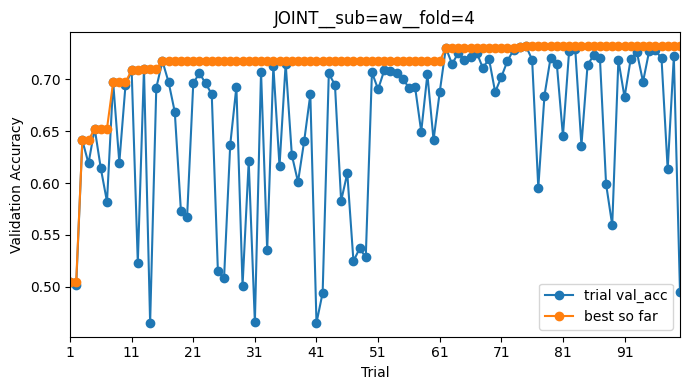

Saved -> optuna_model_results_joint.csv


In [ ]:
# =======================
# Training Loop
# =======================

subjects    = ['aa','al','aw']
fs          = 100
n_folds     = 5
trial_phase = 1

model_rows_joint = []

for subject in subjects:
    print(f"\n===== SUBJECT: {subject} =====")

    cnt_data = all_subject_data[subject]["cnt_data"]
    lapID    = all_subject_data[subject]["lapID"]

    hp_data = filter_data(cnt_data, 2, fs, "high", use_hilbert=True)

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    sample_labels = lapTrue[:, 1] - 1

    for fold in range(n_folds):
        print(f"Fold {fold+1}/{n_folds}")

        test_inds, train_inds = test_train(
            lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
        )

        # Outer-train whitening (once per fold)
        wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

        # -----------------------------
        # Optuna joint tuning
        # -----------------------------
        best, best_val, study_name = optuna_tune_joint(
            wX=wX,
            sample_labels=sample_labels,
            lapID=lapTrue,
            outer_train_inds=train_inds,
            trial_phase=trial_phase,
            n_folds=n_folds,
            which_fold=fold,
            n_trials=100,
            seed=42,
            verbosity=0,
            tune_l2=True,
            l2_range=(-6, -1),
            max_epochs=120,
            storage_path="optuna_studies.db",
            subject=subject,
            model_tag="JOINT",
        )

        # -----------------------------
        # Final training on outer train
        # -----------------------------

        model_kind   = best["model_kind"]
        hidden_nodes = best["hidden_nodes"]
        lr           = best["learn_rate"]
        mag_scale    = best["mag_scale"]
        patience     = best["patience"]

        if model_kind == "timbre":

            _, _, acc = TIMBRE(
                wX, sample_labels,
                test_inds, train_inds,     # (inds_test, inds_train)
                hidden_nodes=hidden_nodes,
                learn_rate=lr,
                mag_scale=mag_scale,
                kernel_unit_norm=best.get("kernel_unit_norm", True),
                patience=patience,
                max_epochs=120,
                verbosity=0,
            )

            model_name = "TIMBRE"

        else:  # bn_l2 branch

            _, _, acc = TIMBRE_BN_L2(
                wX, sample_labels,
                test_inds, train_inds,     # positional inds
                hidden_nodes=hidden_nodes,
                learn_rate=lr,
                batch_size=best["batch_size"],
                patience=best["patience"],
                l2_lambda=best["l2_lambda"],
                mag_scale=mag_scale,
                verbosity=0,
                max_epochs=120,
            )

            model_name = "TIMBRE_BN_L2"

        # -----------------------------
        # Log results
        # -----------------------------
        model_rows_joint.append({
            "Subject": subject,
            "Fold": fold,
            "Study": study_name,
            "Model": model_name,
            "hidden_nodes": int(hidden_nodes),
            "Optuna_Best_ValAcc": float(best_val),
            "Sample_Accuracy": float(acc),
            "learn_rate": float(lr),
            "mag_scale": float(mag_scale),
            "kernel_unit_norm": best.get("kernel_unit_norm"),
            "batch_size": best.get("batch_size"),
            "patience": best.get("patience"),
            "l2_lambda": best.get("l2_lambda"),
        })


# Save everything
df_joint = pd.DataFrame(model_rows_joiny)
df_joint.to_csv("optuna_model_results_joint.csv", index=False)

print("Saved -> optuna_model_results_joint.csv")

# The previous code extracts the best model per fold per subject, not the best model per subject

In [ ]:
# ============================================================
# USER SETTINGS
# ============================================================
subjects = ["aa", "al", "aw"]
storage_path = "optuna_studies.db"   # change if needed
n_folds = 5
trial_phase = 1
fs = 100
max_epochs = 120

TOP_K = 10                  # final top-K subject-level configs to keep
CANDIDATES_PER_FOLD = 8     # how many high-val trials to pull from each fold before dedup/re-ranking


# ============================================================
# STEP 1: PULL CANDIDATE CONFIGS FROM OPTUNA DB
# ============================================================
storage = f"sqlite:///{os.path.abspath(storage_path)}"
study_summaries = optuna.study.get_all_study_summaries(storage=storage)

candidate_rows = []

for s in study_summaries:
    parts = parse_study_name(s.study_name)
    subj = parts.get("sub", None)
    fold = parts.get("fold", None)

    if subj not in subjects:
        continue
    if fold is None:
        continue

    st = optuna.load_study(study_name=s.study_name, storage=storage)
    df_trials = st.trials_dataframe(attrs=("number", "value", "state", "params"))
    df_trials = df_trials[df_trials["state"] == "COMPLETE"].copy()

    if df_trials.empty:
        continue

    # top candidate trials from this fold by inner-val objective
    df_trials = df_trials.sort_values("value", ascending=False).head(CANDIDATES_PER_FOLD).copy()

    for _, row in df_trials.iterrows():
        try:
            cfg = config_from_trial_row(row, parts)
            candidate_rows.append({
                "subject": subj,
                "source_fold_of_trial": int(fold),
                "inner_val_score": float(row["value"]),
                "config_key": config_key(cfg),
                "config": cfg,
                "study_name": s.study_name,
                "trial_number": int(row["number"]),
            })
        except Exception as e:
            print(f"Skipping trial from {s.study_name} due to parse error: {e}")

cand_df = pd.DataFrame(candidate_rows)

if cand_df.empty:
    raise ValueError("No candidate configs were recovered from the Optuna database.")

# Deduplicate identical configs within each subject
cand_df = (
    cand_df.sort_values(["subject", "inner_val_score"], ascending=[True, False])
           .drop_duplicates(subset=["subject", "config_key"])
           .reset_index(drop=True)
)

print(f"Recovered {len(cand_df)} unique candidate configs across subjects.")

# ============================================================
# STEP 2: RE-EVALUATE EACH UNIQUE CONFIG ACROSS ALL SOURCE FOLDS
#         -> this creates subject-level ranking
# ============================================================
subject_level_rows = []

for subject in subjects:
    subj_cands = cand_df[cand_df["subject"] == subject].copy().reset_index(drop=True)
    print(f"\n===== SUBJECT {subject}: evaluating {len(subj_cands)} unique candidate configs across all folds =====")

    for i, r in subj_cands.iterrows():
        cfg = r["config"]
        out = evaluate_config_on_subject_all_folds(
            subject=subject,
            cfg=cfg,
            fs=fs,
            n_folds=n_folds,
            trial_phase=trial_phase,
            max_epochs=max_epochs,
        )

        subject_level_rows.append({
            "source_subject": subject,
            "config_key": r["config_key"],
            "model": cfg["model"],
            "hidden_nodes": cfg["hidden_nodes"],
            "learn_rate": cfg["learn_rate"],
            "mag_scale": cfg["mag_scale"],
            "kernel_unit_norm": cfg.get("kernel_unit_norm", np.nan),
            "batch_size": cfg.get("batch_size", np.nan),
            "patience": cfg.get("patience", np.nan),
            "l2_lambda": cfg.get("l2_lambda", np.nan),
            "best_inner_val_seen": float(r["inner_val_score"]),
            "mean_source_acc": out["mean_acc"],
            "std_source_acc": out["std_acc"],
            "source_fold_accs": json.dumps(out["fold_accs"]),
        })

subject_level_df = pd.DataFrame(subject_level_rows)

# rank within each source subject
subject_level_df = (
    subject_level_df
    .sort_values(["source_subject", "mean_source_acc"], ascending=[True, False])
    .reset_index(drop=True)
)
subject_level_df["rank"] = (
    subject_level_df.groupby("source_subject")["mean_source_acc"]
    .rank(method="first", ascending=False)
    .astype(int)
)

topk_df = (
    subject_level_df[subject_level_df["rank"] <= TOP_K]
    .sort_values(["source_subject", "rank"])
    .reset_index(drop=True)
)

topk_df.to_csv('OUTPUT_TOPK.csv', index=False)
print(f"\nSaved subject-level top-K configs")

# ============================================================
# STEP 3: TRANSFER TOP-K SUBJECT-LEVEL CONFIGS TO ALL TARGET SUBJECTS
#         Evaluate on every fold of each target subject
# ============================================================
xfer_fold_rows = []
xfer_summary_rows = []

for _, r in topk_df.iterrows():
    cfg = {
        "model": r["model"],
        "hidden_nodes": int(r["hidden_nodes"]),
        "learn_rate": float(r["learn_rate"]),
        "mag_scale": float(r["mag_scale"]),
    }

    if r["model"] == "TIMBRE":
        cfg["kernel_unit_norm"] = safe_bool(r["kernel_unit_norm"], True)
    else:
        cfg["batch_size"] = int(r["batch_size"])
        cfg["patience"] = int(r["patience"])
        cfg["l2_lambda"] = float(r["l2_lambda"])

    src = r["source_subject"]
    rank = int(r["rank"])

    for tgt in subjects:
        transfer_fold_accs = []
        baseline_fold_accs = []

        baseline_cfg = {
            "model": r["model"],
            "hidden_nodes": int(r["hidden_nodes"]),
            "learn_rate": float(DEFAULTS[r["model"]]["learn_rate"]),
            "mag_scale": float(DEFAULTS[r["model"]]["mag_scale"]),
        }
        if r["model"] == "TIMBRE":
            baseline_cfg["kernel_unit_norm"] = DEFAULTS[r["model"]].get("kernel_unit_norm", True)
        else:
            baseline_cfg["batch_size"] = int(DEFAULTS[r["model"]].get("batch_size", 64))
            baseline_cfg["patience"] = int(DEFAULTS[r["model"]].get("patience", 1))
            baseline_cfg["l2_lambda"] = float(DEFAULTS[r["model"]].get("l2_lambda", 1e-3))

        for fold in range(n_folds):
            acc_transfer = evaluate_config_on_subject_one_fold(
                subject=tgt,
                cfg=cfg,
                fold=fold,
                fs=fs,
                n_folds=n_folds,
                trial_phase=trial_phase,
                max_epochs=max_epochs,
            )
            acc_base = evaluate_config_on_subject_one_fold(
                subject=tgt,
                cfg=baseline_cfg,
                fold=fold,
                fs=fs,
                n_folds=n_folds,
                trial_phase=trial_phase,
                max_epochs=max_epochs,
            )

            transfer_fold_accs.append(acc_transfer)
            baseline_fold_accs.append(acc_base)

            xfer_fold_rows.append({
                "source_subject": src,
                "target_subject": tgt,
                "rank": rank,
                "fold": fold,
                "model": cfg["model"],
                "hidden_nodes": cfg["hidden_nodes"],
                "source_mean_acc": float(r["mean_source_acc"]),
                "transfer_acc": float(acc_transfer),
                "baseline_acc": float(acc_base),
                "delta_vs_untuned": float(acc_transfer - acc_base),
            })

        xfer_summary_rows.append({
            "source_subject": src,
            "target_subject": tgt,
            "rank": rank,
            "model": cfg["model"],
            "hidden_nodes": cfg["hidden_nodes"],
            "source_mean_acc": float(r["mean_source_acc"]),
            "source_std_acc": float(r["std_source_acc"]),
            "transfer_mean_acc": float(np.mean(transfer_fold_accs)),
            "transfer_std_acc": float(np.std(transfer_fold_accs)),
            "baseline_mean_acc": float(np.mean(baseline_fold_accs)),
            "baseline_std_acc": float(np.std(baseline_fold_accs)),
            "delta_vs_untuned_mean": float(np.mean(np.array(transfer_fold_accs) - np.array(baseline_fold_accs))),
            "transfer_fold_accs": json.dumps([float(x) for x in transfer_fold_accs]),
            "baseline_fold_accs": json.dumps([float(x) for x in baseline_fold_accs]),
        })
df_xfer_foldwise = pd.DataFrame(xfer_fold_rows)
df_xfer_summary = pd.DataFrame(xfer_summary_rows)

df_xfer_foldwise.to_csv('OUTPUT_XFER_FOLDWISE.csv', index=False)
df_xfer_summary.to_csv('OUTPUT_XFER_SUMMARY.csv', index=False)

Patched: run_with_params, evaluate_config_on_subject_one_fold, evaluate_config_on_subject_all_folds
Recovered 120 unique candidate configs across subjects.

===== SUBJECT aw: evaluating 40 unique candidate configs across all folds =====

===== SUBJECT aa: evaluating 40 unique candidate configs across all folds =====

===== SUBJECT al: evaluating 40 unique candidate configs across all folds =====

Saved subject-level top-K configs

Saved foldwise transfer results
Saved summary transfer results 


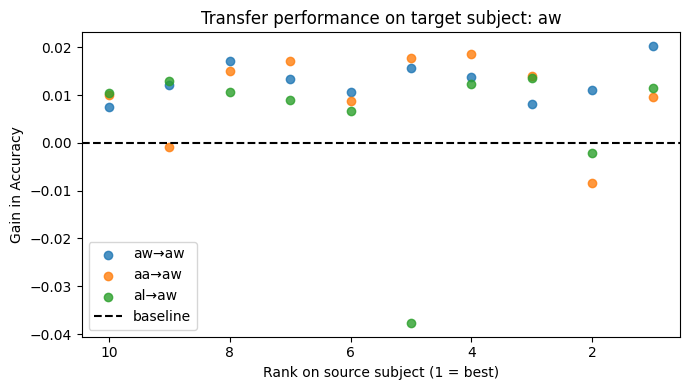

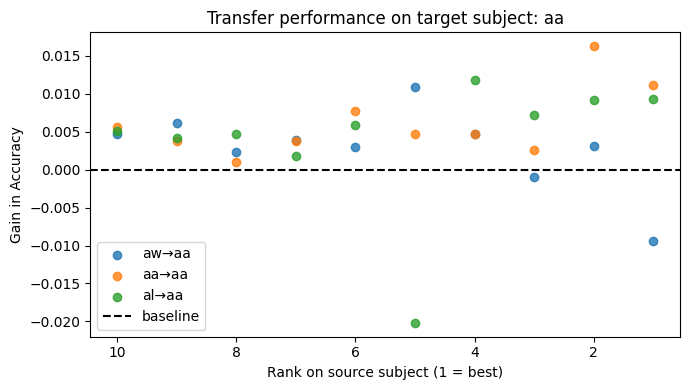

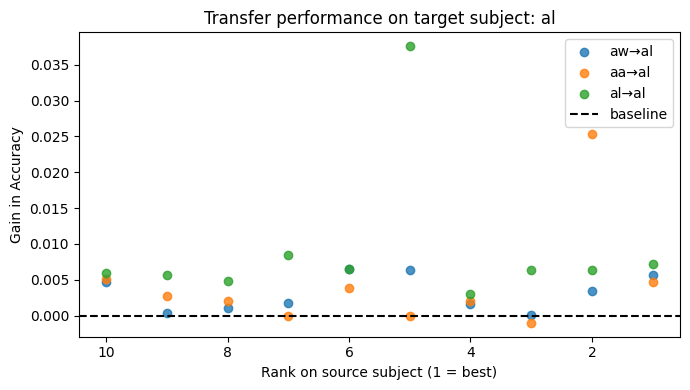

In [ ]:
df_plot = df_xfer_summary.copy()

same_subject = df_plot["source_subject"] == df_plot["target_subject"]

df_plot["plot_acc"] = df_plot["transfer_mean_acc"]
df_plot.loc[same_subject, "plot_acc"] = df_plot.loc[same_subject, "source_mean_acc"]

for tgt in subjects:

    dtgt = df_plot[df_plot["target_subject"] == tgt]

    plt.figure(figsize=(7,4))

    for src in subjects:

        dsrc = dtgt[dtgt["source_subject"] == src]
        dsrc['gain'] = dsrc['plot_acc'] - dsrc['baseline_mean_acc']

        plt.scatter(
            dsrc["rank"],
            dsrc["gain"],
            label=f"{src}→{tgt}",
            alpha=0.8
        )

    baseline_mean = dtgt["baseline_mean_acc"].mean()

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="baseline"
    )

    plt.gca().invert_xaxis()

    plt.xlabel("Rank on source subject (1 = best)")
    plt.ylabel("Gain in Accuracy")
    plt.title(f"Transfer performance on target subject: {tgt}")

    plt.legend()
    plt.tight_layout()
    plt.show()

To better understand whether this method yielded robust sets of hyperparameters, we place the results from the models consistently above baseline across all three subjects with 'good' data.

To isolate the contribution of individual hyperparameters, we constructed one-at-a-time intervention models in which a single hyperparameter was set to its optimized value while all remaining hyperparameters were held at their default values.

In [ ]:
subjects    = ['aw', 'aa', 'al']
fs          = 100
n_folds     = 5
trial_phase = 1

# --------------------------------------------------
# choose fixed hidden_nodes for the intervention study
# --------------------------------------------------
FIXED_HIDDEN_NODES = 0 # can be changed according to desired testing params

# --------------------------------------------------
# extract representative tuned HP values from top_k_df
# treating TIMBRE + TIMBRE_BN_L2 as one family
# --------------------------------------------------
def first_mode(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

top = top_k_df.copy()

best_hp = {}

if "learn_rate" in top.columns:
    x = top["learn_rate"].dropna().astype(float)
    if len(x):
        best_hp["learn_rate"] = float(np.exp(np.mean(np.log(x))))

if "mag_scale" in top.columns:
    x = top["mag_scale"].dropna()
    if len(x):
        best_hp["mag_scale"] = float(first_mode(x))

if "patience" in top.columns:
    x = top["patience"].dropna()
    if len(x):
        best_hp["patience"] = int(first_mode(x))

if "batch_size" in top.columns:
    x = top["batch_size"].dropna()
    if len(x):
        best_hp["batch_size"] = int(first_mode(x))

if "l2_lambda" in top.columns:
    x = top["l2_lambda"].dropna().astype(float)
    x = x[x > 0]
    if len(x):
        best_hp["l2_lambda"] = float(np.exp(np.mean(np.log(x))))

if "kernel_unit_norm" in top.columns:
    x = top["kernel_unit_norm"].dropna()
    if len(x):
        best_hp["kernel_unit_norm"] = bool(first_mode(x))

print("Representative tuned HP values:")
print(best_hp)

# --------------------------------------------------
# one shared default config
# --------------------------------------------------
default_cfg = {
    "learn_rate": 1e-3,
    "mag_scale": 1.0,
    "kernel_unit_norm": True,
    "batch_size": 64,
    "patience": 1,
    "l2_lambda": 0,
    "max_epochs": 120,
    "use_bn_l2": False,
}

# --------------------------------------------------
# intervention configs
# unified TIMBRE family
# --------------------------------------------------
intervention_configs = {
    "default": default_cfg.copy(),

    "learn_rate_only": {
        **default_cfg,
        "learn_rate": best_hp.get("learn_rate", default_cfg["learn_rate"]),
    },

    "mag_scale_only": {
        **default_cfg,
        "mag_scale": best_hp.get("mag_scale", default_cfg["mag_scale"]),
    },

    "patience_only": {
        **default_cfg,
        "patience": best_hp.get("patience", default_cfg["patience"]),
    },

    "kernel_unit_norm_only": {
        **default_cfg,
        "kernel_unit_norm": best_hp.get("kernel_unit_norm", default_cfg["kernel_unit_norm"]),
    },

    # turn on BN/L2 family, but keep everything else at default
    "bn_l2_arch_only": {
        **default_cfg,
        "use_bn_l2": True,
    },

    "batch_size_only": {
        **default_cfg,
        "use_bn_l2": True,
        "batch_size": best_hp.get("batch_size", default_cfg["batch_size"]),
    },

    "l2_lambda_only": {
        **default_cfg,
        "use_bn_l2": True,
        "l2_lambda": best_hp.get("l2_lambda", default_cfg["l2_lambda"]),
    },

    # full tuned plain TIMBRE side
    "full_tuned_no_bn_l2": {
        **default_cfg,
        "learn_rate": best_hp.get("learn_rate", default_cfg["learn_rate"]),
        "mag_scale": best_hp.get("mag_scale", default_cfg["mag_scale"]),
        "patience": best_hp.get("patience", default_cfg["patience"]),
        "kernel_unit_norm": best_hp.get("kernel_unit_norm", default_cfg["kernel_unit_norm"]),
        "use_bn_l2": False,
    },

    # full tuned with BN/L2 side
    "full_tuned_with_bn_l2": {
        **default_cfg,
        "learn_rate": best_hp.get("learn_rate", default_cfg["learn_rate"]),
        "mag_scale": best_hp.get("mag_scale", default_cfg["mag_scale"]),
        "patience": best_hp.get("patience", default_cfg["patience"]),
        "batch_size": best_hp.get("batch_size", default_cfg["batch_size"]),
        "l2_lambda": best_hp.get("l2_lambda", default_cfg["l2_lambda"]),
        "use_bn_l2": True,
    },
}

print("\nIntervention conditions:")
for k in intervention_configs:
    print("-", k, intervention_configs[k])

# --------------------------------------------------
# run intervention study
# --------------------------------------------------
rows = []

for subject in subjects:
    print(f"\n===== SUBJECT: {subject} =====")
    cnt_data = all_subject_data[subject]['cnt_data']
    lapID    = all_subject_data[subject]['lapID']

    hp_data = filter_data(cnt_data, 2, fs, 'high', use_hilbert=True)

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    sample_labels = lapTrue[:, 1] - 1

    for fold in range(n_folds):
        print(f"  Fold {fold+1}/{n_folds}")

        test_inds, train_inds = test_train(
            lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
        )

        wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

        for condition, cfg in intervention_configs.items():
            if cfg["use_bn_l2"]:
                _, _, acc = TIMBRE_BN_L2(
                    wX,
                    sample_labels,
                    test_inds,
                    train_inds,
                    hidden_nodes=FIXED_HIDDEN_NODES,
                    learn_rate=cfg["learn_rate"],
                    batch_size=cfg["batch_size"],
                    patience=cfg["patience"],
                    l2_lambda=cfg["l2_lambda"],
                    mag_scale=cfg["mag_scale"],
                    max_epochs=cfg["max_epochs"],
                    verbosity=0,
                )
                model_variant = "TIMBRE_BN_L2"
            else:
                _, _, acc = TIMBRE(
                    wX,
                    sample_labels,
                    test_inds,
                    train_inds,
                    hidden_nodes=FIXED_HIDDEN_NODES,
                    learn_rate=cfg["learn_rate"],
                    mag_scale=cfg["mag_scale"],
                    kernel_unit_norm=cfg["kernel_unit_norm"],
                    max_epochs=cfg["max_epochs"],
                    patience=cfg["patience"],
                    batch_size=cfg["batch_size"],
                    verbosity=0,
                )
                model_variant = "TIMBRE"

            rows.append({
                "Subject": subject,
                "Fold": fold,
                "Condition": condition,
                "Backend_Model": model_variant,
                "hidden_nodes": FIXED_HIDDEN_NODES,
                "learn_rate": cfg["learn_rate"],
                "mag_scale": cfg["mag_scale"],
                "kernel_unit_norm": cfg["kernel_unit_norm"],
                "batch_size": cfg["batch_size"],
                "patience": cfg["patience"],
                "l2_lambda": cfg["l2_lambda"],
                "use_bn_l2": cfg["use_bn_l2"],
                "Sample_Accuracy": float(acc),
            })

df_timbre_hp_interventions = pd.DataFrame(rows)

summary = (
    df_timbre_hp_interventions
    .groupby(["Subject", "Condition"], as_index=False)
    .agg(
        mean_acc=("Sample_Accuracy", "mean"),
        std_acc=("Sample_Accuracy", "std")
    )
)

overall_summary = (
    df_timbre_hp_interventions
    .groupby("Condition", as_index=False)
    .agg(
        mean_acc=("Sample_Accuracy", "mean"),
        std_acc=("Sample_Accuracy", "std")
    )
    .sort_values("mean_acc", ascending=False)
    .reset_index(drop=True)
)

print("\nSubject-level summary:")
display(summary.sort_values(["Subject", "mean_acc"], ascending=[True, False]))

print("\nOverall summary:")
display(overall_summary)

df_timbre_hp_interventions.to_csv("timbre_hp_interventions_foldwise.csv", index=False)
summary.to_csv("timbre_hp_interventions_by_subject.csv", index=False)
overall_summary.to_csv("timbre_hp_interventions_overall.csv", index=False)

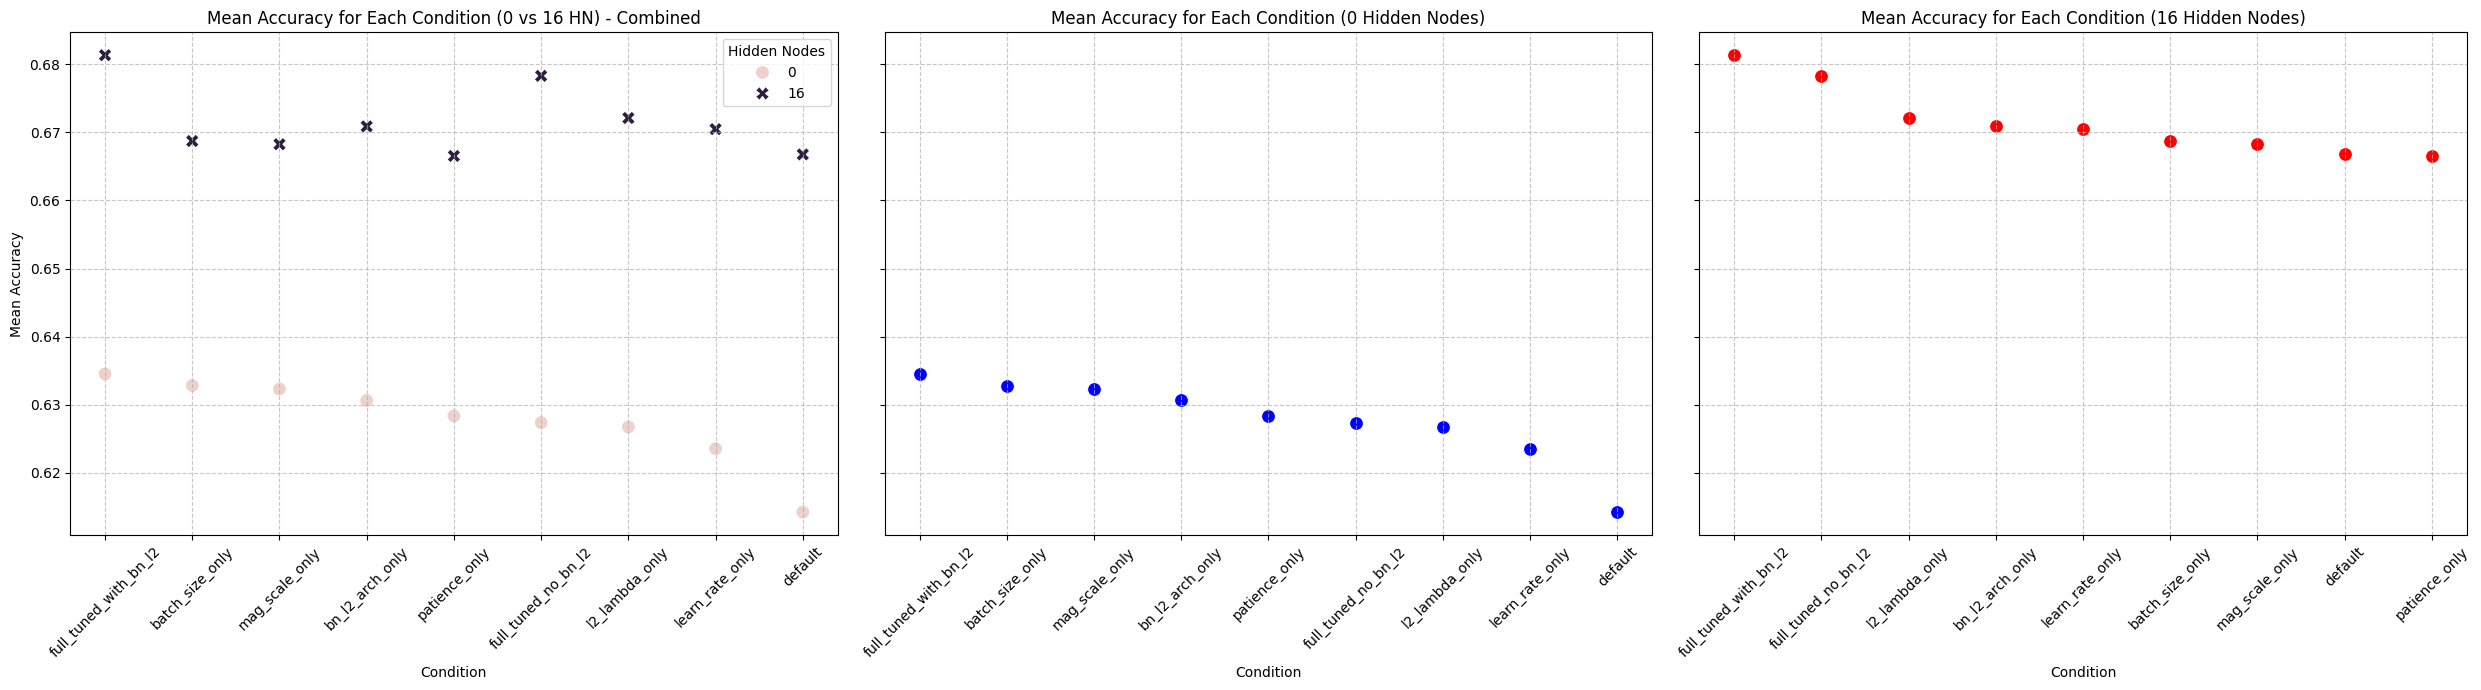

In [ ]:
overall_summary_0hn = pd.read_csv('timbre_hp_interventions_overall.csv')
overall_summary_0hn['hidden_nodes'] = 0

overall_summary_16hn = pd.read_csv('16hn_timbre_hp_interventions_overall.csv')
overall_summary_16hn['hidden_nodes'] = 16

# Create combined summary
combined_summary = pd.concat([overall_summary_0hn.copy(), overall_summary_16hn.copy()], ignore_index=True)

# Filter out 'kernel_unit_norm_only' from all dataframes for consistency
overall_summary_0hn = overall_summary_0hn[overall_summary_0hn['Condition'] != 'kernel_unit_norm_only']
overall_summary_16hn = overall_summary_16hn[overall_summary_16hn['Condition'] != 'kernel_unit_norm_only']
combined_summary = combined_summary[combined_summary['Condition'] != 'kernel_unit_norm_only']

# Create a figure with 1 row and 3 columns for the subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 7), sharey=True)

# Plot 1: Combined View (0hn and 16hn)
sns.scatterplot(
    data=combined_summary,
    x='Condition',
    y='mean_acc',
    hue='hidden_nodes',
    style='hidden_nodes',
    markers=True,
    s=100,
    ax=axes[0]
)
axes[0].set_title('Mean Accuracy for Each Condition (0 vs 16 HN) - Combined')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Mean Accuracy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Hidden Nodes')

sns.scatterplot(
    data=overall_summary_0hn,
    x='Condition',
    y='mean_acc',
    color='blue',
    markers=True,
    s=100,
    ax=axes[1]
)
axes[1].set_title('Mean Accuracy for Each Condition (0 Hidden Nodes)')
axes[1].set_xlabel('Condition')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(
    data=overall_summary_16hn,
    x='Condition',
    y='mean_acc',
    color='red',
    markers=True,
    s=100,
    ax=axes[2]
)
axes[2].set_title('Mean Accuracy for Each Condition (16 Hidden Nodes)')
axes[2].set_xlabel('Condition')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 7. Hyperparameter Search (CSP)


In [ ]:
subjects     = ['aw', 'aa', 'al']
fs           = 100
n_folds      = 5
trial_phase  = 1
TOP_K        = 10
n_trials     = 100
storage_path = "optuna_ccsp.db"

baseline_cfg = {
    "ridge": 1e-3,
    "n_features": 1,
    "C": 1.0,
    "solver": "lbfgs",
    "tol": 1e-4,
}

# =========================================================
# STEP 1: NESTED CV OPTUNA SEARCH, FOLD-LEVEL RESULTS
# =========================================================
fold_rows = []

for subject in subjects:
    print(f"\n===== SUBJECT: {subject} =====")
    cnt_data = all_subject_data[subject]['cnt_data']
    lapID    = all_subject_data[subject]['lapID']

    hp_data = filter_data(cnt_data, 2, fs, 'high', use_hilbert=True)

    print(f"cnt_data shape: {cnt_data.shape}")
    print(f"lapID shape: {lapID.shape}")
    print(f"hp_data shape: {hp_data.shape}")

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    sample_labels = lapTrue[:, 1] - 1

    for fold in range(n_folds):
        print(f"  Fold {fold+1}/{n_folds}")

        test_inds, train_inds = test_train(
            lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
        )

        inner_train_mask, inner_val_mask = inner_split(
            lapTrue, train_inds, trial_phase, n_folds=n_folds, which_fold=fold
        )

        # keep whitening exactly as before
        wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

        def objective(trial):
            ridge      = trial.suggest_float("ridge", 1e-6, 1e1, log=True)
            n_features = trial.suggest_int("n_features", 1, 1)
            C          = trial.suggest_float("C", 1e-4, 1e3, log=True)
            solver     = trial.suggest_categorical("solver", ["lbfgs", "liblinear"])
            tol        = trial.suggest_float("tol", 1e-6, 1e-2, log=True)

            W, _   = csp(wX[inner_train_mask], sample_labels[inner_train_mask], ridge=ridge)
            W_sel  = W[:, :n_features, :].conj()
            W_flat = np.reshape(W_sel, (W.shape[0], -1))

            X_proj = np.dot(wX, W_flat)
            X_feat = np.abs(X_proj)

            Xtr = X_feat[inner_train_mask]
            Xva = X_feat[inner_val_mask]
            ytr = sample_labels[inner_train_mask]
            yva = sample_labels[inner_val_mask]

            clf = LogisticRegression(
                penalty="l2",
                C=C,
                solver=solver,
                tol=tol,
                max_iter=1000
            )
            clf.fit(Xtr, ytr)
            pred = clf.predict(Xva)
            return accuracy_score(yva, pred)

        study_name = f"cCSP__sub={subject}__fold={fold}"
        storage = f"sqlite:///{os.path.abspath(storage_path)}"

        try:
            study = optuna.create_study(
                study_name=study_name,
                storage=storage,
                direction="maximize",
                load_if_exists=True,
            )
        except Exception:
            study = optuna.load_study(study_name=study_name, storage=storage)

        study.optimize(objective, n_trials=n_trials)

        best_params = study.best_trial.params.copy()
        best_val = float(study.best_value)

        ridge      = float(best_params["ridge"])
        n_features = int(best_params["n_features"])
        C          = float(best_params["C"])
        solver     = best_params["solver"]
        tol        = float(best_params["tol"])

        # outer-test evaluation
        W, _   = csp(wX[train_inds], sample_labels[train_inds], ridge=ridge)
        W_sel  = W[:, :n_features, :].conj()
        W_flat = np.reshape(W_sel, (W.shape[0], -1))

        X_proj = np.dot(wX, W_flat)
        X_feat = np.abs(X_proj)

        Xtr = X_feat[train_inds]
        Xte = X_feat[test_inds]
        ytr = sample_labels[train_inds]
        yte = sample_labels[test_inds]

        clf = LogisticRegression(
            penalty="l2",
            C=C,
            solver=solver,
            tol=tol,
            max_iter=1000
        )
        clf.fit(Xtr, ytr)
        acc = accuracy_score(yte, clf.predict(Xte))

        cfg = {
            "ridge": ridge,
            "n_features": n_features,
            "C": C,
            "solver": solver,
            "tol": tol,
        }

        fold_rows.append({
            "Subject": subject,
            "Fold": fold,
            "Model": "cCSP",
            "best_val_acc": best_val,
            "Sample_Accuracy": float(acc),
            "ridge": ridge,
            "n_features": n_features,
            "C": C,
            "solver": solver,
            "tol": tol,
            "config_key": json.dumps(cfg, sort_keys=True),
        })

df_ccsp_fold = pd.DataFrame(fold_rows)
print("\nFold-level cCSP results:")
display(df_ccsp_fold.head())

# =========================================================
# STEP 2: SUBJECT-LEVEL RE-EVALUATION OF UNIQUE CONFIGS
# =========================================================
subject_rows = []

for subject in subjects:
    cnt_data = all_subject_data[subject]['cnt_data']
    lapID    = all_subject_data[subject]['lapID']
    hp_data  = filter_data(cnt_data, 2, fs, 'high', use_hilbert=True)

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    sample_labels = lapTrue[:, 1] - 1

    cand_df = (
        df_ccsp_fold[df_ccsp_fold["Subject"] == subject]
        .sort_values("best_val_acc", ascending=False)
        .drop_duplicates(subset=["config_key"])
        .reset_index(drop=True)
    )

    print(f"\n===== SUBJECT {subject}: evaluating {len(cand_df)} unique cCSP configs across all folds =====")

    for _, r in cand_df.iterrows():
        ridge      = float(r["ridge"])
        n_features = int(r["n_features"])
        C          = float(r["C"])
        solver     = r["solver"]
        tol        = float(r["tol"])

        fold_accs = []

        for fold in range(n_folds):
            test_inds, train_inds = test_train(
                lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
            )

            wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

            W, _   = csp(wX[train_inds], sample_labels[train_inds], ridge=ridge)
            W_sel  = W[:, :n_features, :].conj()
            W_flat = np.reshape(W_sel, (W.shape[0], -1))

            X_proj = np.dot(wX, W_flat)
            X_feat = np.abs(X_proj)

            Xtr = X_feat[train_inds]
            Xte = X_feat[test_inds]
            ytr = sample_labels[train_inds]
            yte = sample_labels[test_inds]

            clf = LogisticRegression(
                penalty="l2",
                C=C,
                solver=solver,
                tol=tol,
                max_iter=1000
            )
            clf.fit(Xtr, ytr)
            pred = clf.predict(Xte)
            fold_accs.append(accuracy_score(yte, pred))

        subject_rows.append({
            "source_subject": subject,
            "model": "cCSP",
            "config_key": r["config_key"],
            "ridge": ridge,
            "n_features": n_features,
            "C": C,
            "solver": solver,
            "tol": tol,
            "best_inner_val_seen": float(r["best_val_acc"]),
            "mean_source_acc": float(np.mean(fold_accs)),
            "std_source_acc": float(np.std(fold_accs)),
            "source_fold_accs": json.dumps([float(x) for x in fold_accs]),
        })

subject_level_ccsp = pd.DataFrame(subject_rows)
subject_level_ccsp = subject_level_ccsp.sort_values(
    ["source_subject", "mean_source_acc"],
    ascending=[True, False]
).reset_index(drop=True)

subject_level_ccsp["rank"] = (
    subject_level_ccsp.groupby("source_subject")["mean_source_acc"]
    .rank(method="first", ascending=False)
    .astype(int)
)

topk_ccsp_df = subject_level_ccsp[subject_level_ccsp["rank"] <= TOP_K].copy().reset_index(drop=True)

print("\nTop-K cCSP configs:")
display(topk_ccsp_df)

# =========================================================
# STEP 3: TRANSFER TOP-K CONFIGS TO OTHER SUBJECTS
# =========================================================
xfer_rows = []

for _, r in topk_ccsp_df.iterrows():
    src        = r["source_subject"]
    rank       = int(r["rank"])
    ridge      = float(r["ridge"])
    n_features = 1
    C          = float(r["C"])
    solver     = r["solver"]
    tol        = float(r["tol"])

    for tgt in subjects:
        cnt_data = all_subject_data[tgt]['cnt_data']
        lapID    = all_subject_data[tgt]['lapID']
        hp_data  = filter_data(cnt_data, 2, fs, 'high', use_hilbert=True)

        valid_mask    = lapID[:, 2].astype(bool)
        valid_hp_data = hp_data[valid_mask]
        lapTrue       = lapID[valid_mask]
        sample_labels = lapTrue[:, 1] - 1

        transfer_fold_accs = []
        baseline_fold_accs = []

        for fold in range(n_folds):
            test_inds, train_inds = test_train(
                lapTrue, trial_phase, n_folds=n_folds, which_fold=fold
            )

            wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

            # transferred config
            W, _   = csp(wX[train_inds], sample_labels[train_inds], ridge=ridge)
            W_sel  = W[:, :n_features, :].conj()
            W_flat = np.reshape(W_sel, (W.shape[0], -1))

            X_proj = np.dot(wX, W_flat)
            X_feat = np.abs(X_proj)

            Xtr = X_feat[train_inds]
            Xte = X_feat[test_inds]
            ytr = sample_labels[train_inds]
            yte = sample_labels[test_inds]

            clf = LogisticRegression(
                penalty="l2",
                C=C,
                solver=solver,
                tol=tol,
                max_iter=1000
            )
            clf.fit(Xtr, ytr)
            transfer_acc = accuracy_score(yte, clf.predict(Xte))

            # baseline config
            Wb, _   = csp(wX[train_inds], sample_labels[train_inds], ridge=baseline_cfg["ridge"])
            Wb_sel  = Wb[:, :baseline_cfg["n_features"], :].conj()
            Wb_flat = np.reshape(Wb_sel, (Wb.shape[0], -1))

            Xb_proj = np.dot(wX, Wb_flat)
            Xb_feat = np.abs(Xb_proj)

            Xb_tr = Xb_feat[train_inds]
            Xb_te = Xb_feat[test_inds]

            clfb = LogisticRegression(
                penalty="l2",
                C=baseline_cfg["C"],
                solver=baseline_cfg["solver"],
                tol=baseline_cfg["tol"],
                max_iter=1000
            )
            clfb.fit(Xb_tr, ytr)
            baseline_acc = accuracy_score(yte, clfb.predict(Xb_te))

            transfer_fold_accs.append(transfer_acc)
            baseline_fold_accs.append(baseline_acc)

        xfer_rows.append({
            "source_subject": src,
            "target_subject": tgt,
            "config_key": r["config_key"],
            "rank": rank,
            "model": "cCSP",
            "ridge": ridge,
            "n_features": n_features,
            "C": C,
            "solver": solver,
            "tol": tol,
            "source_mean_acc": float(r["mean_source_acc"]),
            "source_std_acc": float(r["std_source_acc"]),
            "transfer_mean_acc": float(np.mean(transfer_fold_accs)),
            "transfer_std_acc": float(np.std(transfer_fold_accs)),
            "baseline_mean_acc": float(np.mean(baseline_fold_accs)),
            "baseline_std_acc": float(np.std(baseline_fold_accs)),
            "delta_vs_untuned_mean": float(np.mean(np.array(transfer_fold_accs) - np.array(baseline_fold_accs))),
            "transfer_fold_accs": json.dumps([float(x) for x in transfer_fold_accs]),
            "baseline_fold_accs": json.dumps([float(x) for x in baseline_fold_accs]),
        })

df_ccsp_xfer_summary = pd.DataFrame(xfer_rows)

print("\ncCSP transfer summary:")
display(df_ccsp_xfer_summary.sort_values(["source_subject", "rank", "target_subject"]))

# save
df_ccsp_fold.to_csv("ccsp_fold_level_optuna_results.csv", index=False)
topk_ccsp_df.to_csv("ccsp_topk_subject_level_configs.csv", index=False)
df_ccsp_xfer_summary.to_csv("ccsp_transfer_summary.csv", index=False)


===== SUBJECT: aw =====
cnt_data shape: (282838, 118)
lapID shape: (282838, 3)
hp_data shape: (282838, 118)
  Fold 1/5


[I 2026-04-11 02:10:53,518] Using an existing study with name 'cCSP__sub=aw__fold=0' instead of creating a new one.
[I 2026-04-11 02:10:53,780] Trial 91 finished with value: 0.521025641025641 and parameters: {'ridge': 1.0579402379499486e-05, 'n_features': 1, 'C': 0.00027909866293913894, 'solver': 'lbfgs', 'tol': 1.5967295533907416e-05}. Best is trial 65 with value: 0.5590955806783144.
[I 2026-04-11 02:10:54,531] Trial 92 finished with value: 0.558974358974359 and parameters: {'ridge': 1.4532684388133221, 'n_features': 1, 'C': 0.00016337888339264798, 'solver': 'lbfgs', 'tol': 3.852298449278011e-05}. Best is trial 65 with value: 0.5590955806783144.
[I 2026-04-11 02:10:54,902] Trial 93 finished with value: 0.5579487179487179 and parameters: {'ridge': 0.3697096986057629, 'n_features': 1, 'C': 0.00017700835940628556, 'solver': 'lbfgs', 'tol': 1.0927752153589473e-05}. Best is trial 65 with value: 0.5590955806783144.
[I 2026-04-11 02:10:55,247] Trial 94 finished with value: 0.5579487179487179

  Fold 2/5


[I 2026-04-11 02:11:20,529] Using an existing study with name 'cCSP__sub=aw__fold=1' instead of creating a new one.
[I 2026-04-11 02:11:20,736] Trial 30 finished with value: 0.4780439121756487 and parameters: {'ridge': 0.0014267060955476312, 'n_features': 1, 'C': 1.937012433450386, 'solver': 'liblinear', 'tol': 0.0004932000594741587}. Best is trial 22 with value: 0.5018339446482161.
[I 2026-04-11 02:11:20,929] Trial 31 finished with value: 0.49334664005322687 and parameters: {'ridge': 0.011942439276376395, 'n_features': 1, 'C': 0.00010703420453056773, 'solver': 'liblinear', 'tol': 0.006378246808753838}. Best is trial 22 with value: 0.5018339446482161.
[I 2026-04-11 02:11:21,135] Trial 32 finished with value: 0.49201596806387227 and parameters: {'ridge': 0.09871521215215082, 'n_features': 1, 'C': 0.00013814427850012426, 'solver': 'liblinear', 'tol': 1.2725282389058188e-06}. Best is trial 22 with value: 0.5018339446482161.
[I 2026-04-11 02:11:21,309] Trial 33 finished with value: 0.48935

  Fold 3/5


...

,Subject,Fold,Model,best_val_acc,Sample_Accuracy,ridge,n_features,C,solver,tol,config_key
0,aw,0,cCSP,0.564103,0.573810,3.151459,1,0.000247,lbfgs,0.001318,"{""C"": 0.00024687361308636997, ""n_features"": 1,..."
1,aw,1,cCSP,0.501834,0.595584,0.004410,1,0.000132,liblinear,0.002256,"{""C"": 0.0001324444209907209, ""n_features"": 1, ..."
2,aw,2,cCSP,0.653210,0.551688,0.000034,1,0.000131,liblinear,0.000025,"{""C"": 0.00013143139628434689, ""n_features"": 1,..."
3,aw,3,cCSP,0.610056,0.550130,0.049220,1,13.967100,lbfgs,0.009940,"{""C"": 13.967099580387535, ""n_features"": 1, ""ri..."
4,aw,4,cCSP,0.670615,0.532857,0.123111,1,0.945886,lbfgs,0.000042,"{""C"": 0.9458862030951329, ""n_features"": 1, ""ri..."



===== SUBJECT aw: evaluating 5 unique cCSP configs across all folds =====

===== SUBJECT aa: evaluating 5 unique cCSP configs across all folds =====

===== SUBJECT al: evaluating 5 unique cCSP configs across all folds =====

Top-K cCSP configs:


,source_subject,model,config_key,ridge,n_features,C,solver,tol,best_inner_val_seen,mean_source_acc,std_source_acc,source_fold_accs,rank
0,aa,cCSP,"{""C"": 0.00014660112468636396, ""n_features"": 1,...",3.259008,1,0.000147,lbfgs,0.000007,0.598450,0.570056,0.007930,"[0.5647899159663865, 0.581764705882353, 0.5644...",1
1,aa,cCSP,"{""C"": 3.52994343513055, ""n_features"": 1, ""ridg...",0.095862,1,3.529943,liblinear,0.000004,0.562007,0.570010,0.009854,"[0.5649579831932773, 0.5834453781512605, 0.565...",2
2,aa,cCSP,"{""C"": 0.00013419158217381244, ""n_features"": 1,...",0.166819,1,0.000134,lbfgs,0.000157,0.596286,0.569940,0.009102,"[0.5645378151260504, 0.5839495798319327, 0.566...",3
3,aa,cCSP,"{""C"": 0.39077857470440813, ""n_features"": 1, ""r...",0.006610,1,0.390779,lbfgs,0.000001,0.566399,0.568521,0.009421,"[0.5642857142857143, 0.5811764705882353, 0.563...",4
4,aa,cCSP,"{""C"": 212.47538775470056, ""n_features"": 1, ""ri...",9.056082,1,212.475388,liblinear,0.000150,0.580196,0.568410,0.007689,"[0.5652941176470588, 0.5784033613445378, 0.563...",5
5,al,cCSP,"{""C"": 1.219699010339088, ""n_features"": 1, ""rid...",0.210051,1,1.219699,lbfgs,0.000097,0.737143,0.754484,0.012428,"[0.7460248447204969, 0.7358095238095238, 0.771...",1
6,al,cCSP,"{""C"": 0.004728070488433001, ""n_features"": 1, ""...",0.000948,1,0.004728,lbfgs,0.000264,0.781477,0.754401,0.012571,"[0.7447826086956522, 0.7364444444444445, 0.772...",2
7,al,cCSP,"{""C"": 888.0874459168068, ""n_features"": 1, ""rid...",0.000002,1,888.087446,liblinear,0.000028,0.742775,0.754222,0.012194,"[0.7462732919254659, 0.7357460317460317, 0.771...",3
8,al,cCSP,"{""C"": 62.592594039659986, ""n_features"": 1, ""ri...",0.052372,1,62.592594,lbfgs,0.000153,0.776750,0.754122,0.012189,"[0.7458385093167702, 0.7358095238095238, 0.771...",4
9,al,cCSP,"{""C"": 0.0003285075334238621, ""n_features"": 1, ...",0.000244,1,0.000329,lbfgs,0.000002,0.752176,0.752634,0.012922,"[0.7392546583850932, 0.7362539682539683, 0.769...",5



cCSP transfer summary:


,source_subject,target_subject,config_key,rank,model,ridge,n_features,C,solver,tol,source_mean_acc,source_std_acc,transfer_mean_acc,transfer_std_acc,baseline_mean_acc,baseline_std_acc,delta_vs_untuned_mean,transfer_fold_accs,baseline_fold_accs
1,aa,aa,"{""C"": 0.00014660112468636396, ""n_features"": 1,...",1,cCSP,3.259008,1,0.000147,lbfgs,0.000007,0.570056,0.007930,0.569979,0.009841,0.569807,0.009495,1.716323e-04,"[0.5618487394957983, 0.583109243697479, 0.5664...","[0.564201680672269, 0.5833613445378151, 0.5651..."
2,aa,al,"{""C"": 0.00014660112468636396, ""n_features"": 1,...",1,cCSP,3.259008,1,0.000147,lbfgs,0.000007,0.570056,0.007930,0.751431,0.013192,0.754378,0.012282,-2.946948e-03,"[0.7359627329192546, 0.7360634920634921, 0.768...","[0.7462111801242236, 0.7358095238095238, 0.771..."
0,aa,aw,"{""C"": 0.00014660112468636396, ""n_features"": 1,...",1,cCSP,3.259008,1,0.000147,lbfgs,0.000007,0.570056,0.007930,0.566583,0.018797,0.554654,0.018357,1.192900e-02,"[0.5745238095238095, 0.5958441558441558, 0.556...","[0.5697619047619048, 0.5825974025974026, 0.538..."
4,aa,aa,"{""C"": 3.52994343513055, ""n_features"": 1, ""ridg...",2,cCSP,0.095862,1,3.529943,liblinear,0.000004,0.570010,0.009854,0.567796,0.011100,0.567745,0.011065,5.092946e-05,"[0.5646218487394958, 0.5832773109243697, 0.557...","[0.5645378151260504, 0.5831932773109244, 0.557..."
5,aa,al,"{""C"": 3.52994343513055, ""n_features"": 1, ""ridg...",2,cCSP,0.095862,1,3.529943,liblinear,0.000004,0.570010,0.009854,0.754188,0.012311,0.754226,0.012314,-3.810779e-05,"[0.7457763975155279, 0.7357460317460317, 0.771...","[0.7458385093167702, 0.7358095238095238, 0.771..."
3,aa,aw,"{""C"": 3.52994343513055, ""n_features"": 1, ""ridg...",2,cCSP,0.095862,1,3.529943,liblinear,0.000004,0.570010,0.009854,0.552455,0.018345,0.552242,0.018645,2.129870e-04,"[0.5680952380952381, 0.5776623376623377, 0.539...","[0.5680952380952381, 0.577922077922078, 0.5384..."
7,aa,aa,"{""C"": 0.00013419158217381244, ""n_features"": 1,...",3,cCSP,0.166819,1,0.000134,lbfgs,0.000157,0.569940,0.009102,0.569121,0.010224,0.568710,0.009632,4.110008e-04,"[0.563109243697479, 0.5833613445378151, 0.5647...","[0.5653781512605042, 0.5831932773109244, 0.561..."
8,aa,al,"{""C"": 0.00013419158217381244, ""n_features"": 1,...",3,cCSP,0.166819,1,0.000134,lbfgs,0.000157,0.569940,0.009102,0.750903,0.013027,0.753867,0.012214,-2.963875e-03,"[0.735527950310559, 0.7359365079365079, 0.7675...","[0.7452795031055901, 0.7358095238095238, 0.771..."
6,aa,aw,"{""C"": 0.00013419158217381244, ""n_features"": 1,...",3,cCSP,0.166819,1,0.000134,lbfgs,0.000157,0.569940,0.009102,0.567764,0.022289,0.554683,0.020949,1.308052e-02,"[0.5721428571428572, 0.6051948051948052, 0.559...","[0.5692857142857143, 0.5859740259740259, 0.544..."
10,aa,aa,"{""C"": 0.39077857470440813, ""n_features"": 1, ""r...",4,cCSP,0.006610,1,0.390779,lbfgs,0.000001,0.568521,0.009421,0.568680,0.010792,0.568715,0.010787,-3.463203e-05,"[0.5652100840336134, 0.5853781512605042, 0.558...","[0.5652100840336134, 0.5853781512605042, 0.558..."


Best average cCSP HPs: {'ridge': 0.02038197468077698, 'C': 0.07989118457623098, 'tol': 7.012832512803267e-05, 'solver': 'lbfgs'}
Best average TIMBRE HPs: {'learn_rate': 0.00026449834749842647, 'mag_scale': 0.25, 'patience': 2, 'kernel_unit_norm': True, 'batch_size': 32, 'l2_lambda': 0.00011616264225688433, 'use_bn_l2': True}
Running training loop ...

===== SUBJECT: AA =====
  fold=0  n=1  TIMBRE_default=0.539  TIMBRE_opt=0.561  cCSP_default=0.566  cCSP_opt=0.566  rCSP_default=0.524  
  fold=0  n=2  TIMBRE_default=0.565  TIMBRE_opt=0.572  cCSP_default=0.579  cCSP_opt=0.579  rCSP_default=0.561  
  fold=0  n=4  TIMBRE_default=0.567  TIMBRE_opt=0.582  cCSP_default=0.574  cCSP_opt=0.574  rCSP_default=0.566  
  fold=0  n=8  TIMBRE_default=0.574  TIMBRE_opt=0.585  cCSP_default=0.583  cCSP_opt=0.583  rCSP_default=0.573  
  fold=1  n=1  TIMBRE_default=0.519  TIMBRE_opt=0.577  cCSP_default=0.583  cCSP_opt=0.582  rCSP_default=0.528  
  fold=1  n=2  TIMBRE_default=0.557  TIMBRE_opt=0.581  cCSP_de

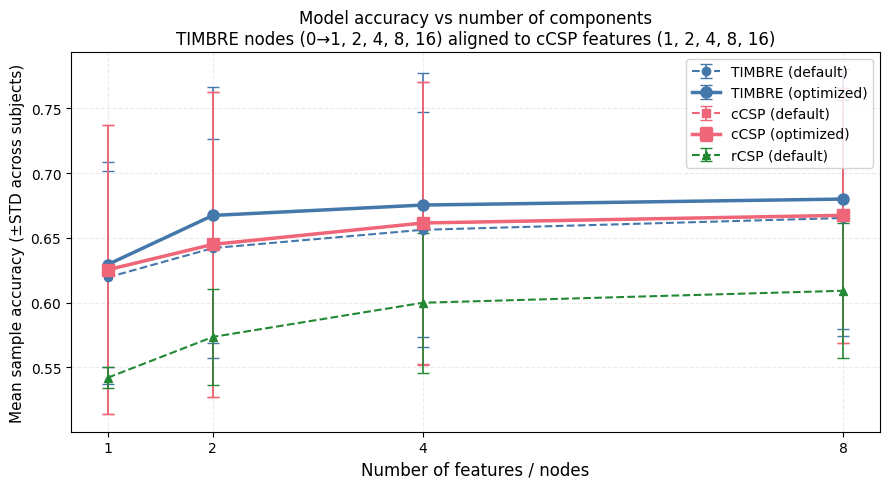

[✓] Saved → comparison_accuracy_per_subject.png


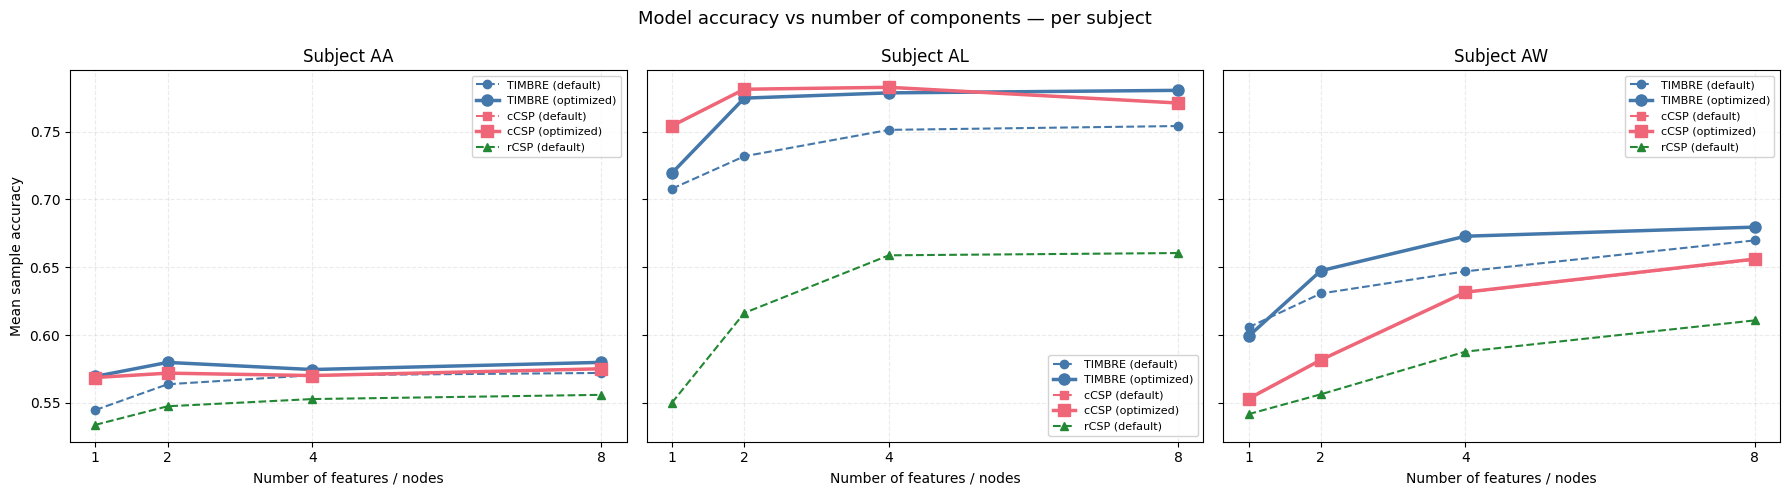


Done.


In [ ]:
# ================================================================
# COMPARISON PIPELINE
# 1. Derive best average cCSP HPs across subjects
# 2. Run training loop: TIMBRE / cCSP / rCSP (default & optimized)
#    across n_features = [1, 2, 4, 8, 16]
# 3. Plot mean accuracy vs #features (aggregate across subjects)
# ================================================================
# Requirements: all helpers, all_subject_data already loaded.
#   TIMBRE, TIMBRE_BN_L2, csp, test_train, helpers, filter_data,
#   LogisticRegression, accuracy_score
# CSVs needed: OUTPUT_TOPK.csv, ccsp_topk_subject_level_configs.csv
# ================================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ── Settings ─────────────────────────────────────────────────────
SUBJECTS     = ["aa", "al", "aw"]
FS           = 100
N_FOLDS      = 5
TRIAL_PHASE  = 1
MAX_EPOCHS   = 120

# n_features sweep (x-axis).  TIMBRE hn=0 → 1 complex node → n_plot=1
N_FEATURES   = [1, 2, 4, 8]

# TIMBRE hidden_nodes that align to N_FEATURES
# hn=0 → 2 output units = 1 complex node → n_plot=1

TIMBRE_HN_MAP = {1: 0, 2: 4, 4: 8, 8: 16}   # n_plot → hidden_nodes

RESULTS_CACHE = "comparison_results.csv"
LOAD_CACHED   = False    # set False to rerun the training loop

# ── 1.  Best average cCSP HPs ────────────────────────────────────
topk_ccsp = pd.read_csv("ccsp_topk_subject_level_configs.csv")
topk_ccsp = topk_ccsp.rename(columns={"source_subject": "Subject",
                                       "mean_source_acc": "Sample_Accuracy"})

def _geomean(s):
    s = s.dropna().astype(float)
    s = s[s > 0]
    return float(np.exp(np.mean(np.log(s)))) if len(s) else np.nan

def _mode1(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

best_ccsp_hp = {
    "ridge":  _geomean(topk_ccsp["ridge"]),
    "C":      _geomean(topk_ccsp["C"]),
    "tol":    _geomean(topk_ccsp["tol"]),
    "solver": _mode1(topk_ccsp["solver"]),
}
print("Best average cCSP HPs:", best_ccsp_hp)

# ── 2.  Best average TIMBRE HPs ──────────────────────────────────
topk_timbre = pd.read_csv("OUTPUT_TOPK.csv")
topk_timbre = topk_timbre.rename(columns={"source_subject": "Subject",
                                           "mean_source_acc": "Sample_Accuracy",
                                           "model": "Model"})

best_timbre_hp = {
    "learn_rate":      _geomean(topk_timbre["learn_rate"]),
    "mag_scale":       float(_mode1(topk_timbre["mag_scale"])),
    "patience":        int(_mode1(topk_timbre["patience"])),
    "kernel_unit_norm": True,   # NaN for BN_L2 rows; default True for plain TIMBRE
    "batch_size":       None,
    "l2_lambda":       _geomean(topk_timbre["l2_lambda"]),
    "use_bn_l2":       False,   # optimized plain TIMBRE only
}
# If most top configs are BN_L2, flip flag
if topk_timbre["Model"].str.contains("BN|L2", case=False).mean() > 0.5:
    best_timbre_hp["use_bn_l2"] = True
    best_timbre_hp["batch_size"] = int(_mode1(topk_timbre["batch_size"].dropna()))
print("Best average TIMBRE HPs:", best_timbre_hp)

# ── 3.  HP registry ──────────────────────────────────────────────
# Each entry: model_tag, model_family, hp_dict
# model_family: "TIMBRE" | "cCSP" | "rCSP"
HP_REGISTRY = {
    "TIMBRE_default": {
        "family": "TIMBRE",
        "learn_rate": 1e-3, "mag_scale": 1.0, "kernel_unit_norm": True,
        "patience": 1, "batch_size": None, "l2_lambda": 0.0,
        "use_bn_l2": False,
    },
    "TIMBRE_opt": {
        "family": "TIMBRE",
        **{k: v for k, v in best_timbre_hp.items() if k != "use_bn_l2"},
        "use_bn_l2": best_timbre_hp["use_bn_l2"],
    },
    "cCSP_default": {
        "family": "cCSP",
        "ridge": 1e-3, "C": 1.0, "solver": "lbfgs", "tol": 1e-4,
    },
    "cCSP_opt": {
        "family": "cCSP",
        **best_ccsp_hp,
    },
    "rCSP_default": {
        "family": "rCSP",
        "ridge": 1e-3, "C": 1.0, "solver": "lbfgs", "tol": 1e-4,
    },
}

# ── 4.  Training helpers ─────────────────────────────────────────
def run_timbre(wX, y, test_inds, train_inds, hn, hp):
    if hp["use_bn_l2"]:
        _, _, acc = TIMBRE_BN_L2(
            wX, y, test_inds, train_inds,
            hidden_nodes=hn,
            learn_rate=float(hp["learn_rate"]),
            batch_size=int(hp["batch_size"] or 64),
            patience=int(hp["patience"]),
            l2_lambda=float(hp["l2_lambda"]),
            mag_scale=float(hp["mag_scale"]),
            max_epochs=MAX_EPOCHS, verbosity=0,
        )
    else:
        _, _, acc = TIMBRE(
            wX, y, test_inds, train_inds,
            hidden_nodes=hn,
            learn_rate=float(hp["learn_rate"]),
            mag_scale=float(hp["mag_scale"]),
            kernel_unit_norm=bool(hp["kernel_unit_norm"]),
            patience=int(hp["patience"]),
            batch_size=hp["batch_size"],
            max_epochs=MAX_EPOCHS, verbosity=0,
        )
    return float(acc)

def run_ccsp(wX, y, test_inds, train_inds, n_features, hp, real=False):
    data = np.real(wX) if real else wX
    W, _ = csp(data[train_inds], y[train_inds], ridge=float(hp["ridge"]))
    W_sel  = W[:, :n_features, :]
    if not real:
        W_sel = W_sel.conj()
    W_flat = W_sel.reshape(W.shape[0], -1)
    X_feat = np.abs(np.dot(data, W_flat))
    clf = LogisticRegression(
        penalty="l2", C=float(hp["C"]),
        solver=str(hp["solver"]), tol=float(hp["tol"]), max_iter=1000
    )
    clf.fit(X_feat[train_inds], y[train_inds])
    return float(accuracy_score(y[test_inds], clf.predict(X_feat[test_inds])))

# ── 5.  Training loop ────────────────────────────────────────────
if LOAD_CACHED and os.path.exists(RESULTS_CACHE):
    print(f"[✓] Loading cached results from '{RESULTS_CACHE}' ...")
    rows_df = pd.read_csv(RESULTS_CACHE)
else:
    print("Running training loop ...")
    rows = []

    for subject in SUBJECTS:
        print(f"\n===== SUBJECT: {subject.upper()} =====")
        cnt_data = all_subject_data[subject]["cnt_data"]
        lapID    = all_subject_data[subject]["lapID"]
        hp_data  = filter_data(cnt_data, 2, FS, "high", use_hilbert=True)

        valid_mask    = lapID[:, 2].astype(bool)
        valid_hp_data = hp_data[valid_mask]
        lapTrue       = lapID[valid_mask]
        y             = lapTrue[:, 1] - 1

        for fold in range(N_FOLDS):
            test_inds, train_inds = test_train(
                lapTrue, TRIAL_PHASE, n_folds=N_FOLDS, which_fold=fold
            )
            wX, _, _ = helpers.whiten(valid_hp_data, train_inds)

            for n_plot in N_FEATURES:
                print(f"  fold={fold}  n={n_plot}", end="  ")

                for tag, hp in HP_REGISTRY.items():
                    family = hp["family"]

                    if family == "TIMBRE":
                        hn = TIMBRE_HN_MAP[n_plot]
                        acc = run_timbre(wX, y, test_inds, train_inds, hn, hp)

                    elif family == "cCSP":
                        acc = run_ccsp(wX, y, test_inds, train_inds,
                                       n_features=n_plot, hp=hp, real=False)

                    elif family == "rCSP":
                        acc = run_ccsp(wX, y, test_inds, train_inds,
                                       n_features=n_plot, hp=hp, real=True)

                    rows.append({
                        "Subject":         subject,
                        "Fold":            fold,
                        "Model":           tag,
                        "n_features":      n_plot,
                        "Sample_Accuracy": acc,
                    })
                    print(f"{tag}={acc:.3f}", end="  ")
                print()

    rows_df = pd.DataFrame(rows)
    rows_df.to_csv(RESULTS_CACHE, index=False)
    print(f"\n[✓] Results saved → {RESULTS_CACHE}")

print(rows_df.groupby(["Model", "n_features"])["Sample_Accuracy"].mean().unstack())

# ── 6.  Plot ─────────────────────────────────────────────────────
# Style: default models thin/dashed, optimized thick/solid
STYLE = {
    "TIMBRE_default":  dict(color="#4477AA", ls="--", lw=1.5, marker="o", ms=6),
    "TIMBRE_opt":      dict(color="#4477AA", ls="-",  lw=2.5, marker="o", ms=8),
    "cCSP_default":    dict(color="#EE6677", ls="--", lw=1.5, marker="s", ms=6),
    "cCSP_opt":        dict(color="#EE6677", ls="-",  lw=2.5, marker="s", ms=8),
    "rCSP_default":    dict(color="#228833", ls="--", lw=1.5, marker="^", ms=6),
}
LABEL = {
    "TIMBRE_default": "TIMBRE (default)",
    "TIMBRE_opt":     "TIMBRE (optimized)",
    "cCSP_default":   "cCSP (default)",
    "cCSP_opt":       "cCSP (optimized)",
    "rCSP_default":   "rCSP (default)",
}

# Aggregate: mean per subject first, then across subjects → SEM
per_subj = (
    rows_df
    .groupby(["Subject", "Model", "n_features"])["Sample_Accuracy"]
    .mean()
    .reset_index()
)
agg = (
    per_subj
    .groupby(["Model", "n_features"])["Sample_Accuracy"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

for tag in STYLE:
    gm = agg[agg["Model"] == tag].sort_values("n_features")
    if gm.empty:
        continue
    s = STYLE[tag]
    ax.errorbar(
        gm["n_features"], gm["mean"], yerr=gm["std"].fillna(0),
        label=LABEL[tag],
        color=s["color"], ls=s["ls"], lw=s["lw"],
        marker=s["marker"], markersize=s["ms"],
        capsize=4, elinewidth=1.2,
    )

ax.set_xlabel("Number of features / nodes", fontsize=12)
ax.set_ylabel("Mean sample accuracy (±STD across subjects)", fontsize=11)
ax.set_title("Model accuracy vs number of components\n"
             "TIMBRE nodes (0→1, 2, 4, 8, 16) aligned to cCSP features (1, 2, 4, 8, 16)",
             fontsize=12)
ax.set_xticks(N_FEATURES)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.25, linestyle="--")
plt.tight_layout()
plt.savefig("comparison_accuracy_vs_nfeatures.png", dpi=150, bbox_inches="tight")
print("[✓] Saved → comparison_accuracy_vs_nfeatures.png")
plt.show()

# ── 7.  Per-subject version ──────────────────────────────────────
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(6 * len(SUBJECTS), 5),
                         sharey=True)

for ax, subject in zip(axes, SUBJECTS):
    subj_df = per_subj[per_subj["Subject"] == subject]
    for tag in STYLE:
        gm = subj_df[subj_df["Model"] == tag].sort_values("n_features")
        if gm.empty:
            continue
        s = STYLE[tag]
        ax.plot(gm["n_features"], gm["Sample_Accuracy"],
                label=LABEL[tag],
                color=s["color"], ls=s["ls"], lw=s["lw"],
                marker=s["marker"], markersize=s["ms"])
    ax.set_title(f"Subject {subject.upper()}", fontsize=12)
    ax.set_xlabel("Number of features / nodes", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Mean sample accuracy", fontsize=10)
    ax.set_xticks(N_FEATURES)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.legend(fontsize=8, framealpha=0.85)

fig.suptitle("Model accuracy vs number of components — per subject", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_accuracy_per_subject.png", dpi=150, bbox_inches="tight")
print("[✓] Saved → comparison_accuracy_per_subject.png")
plt.show()

print("\nDone.")

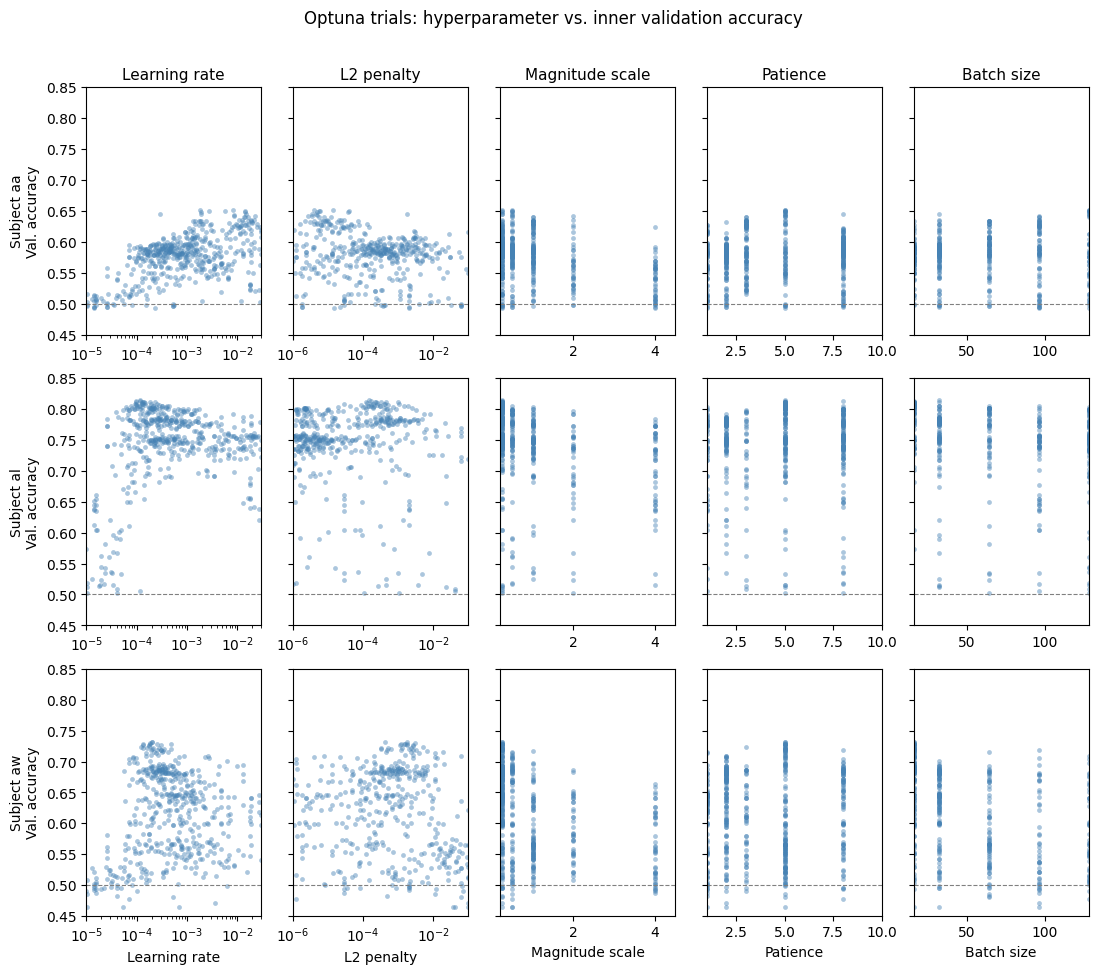

In [ ]:
df = pd.read_csv("optuna_trials_all.csv")
# derive l2_lambda from log10 column where present
df["l2_lambda"] = np.where(
    df["params_log10_l2_lambda"].notna(),
    10 ** df["params_log10_l2_lambda"],
    np.nan
)

subjects = sorted(df["subject"].dropna().unique())
params = [
    ("params_learn_rate", "Learning rate",       True,  (1e-5, 3e-2)),
    ("l2_lambda",         "L2 penalty",          True,  (1e-6, 1e-1)),
    ("params_mag_scale",  "Magnitude scale",     False, (0.2,  4.5)),
    ("params_patience",   "Patience",            False, (1,    10)),
    ("params_batch_size", "Batch size",          False, (16,   128)),
]

fig, axes = plt.subplots(
    nrows=len(subjects),
    ncols=len(params),
    figsize=(11, 3.2 * len(subjects)),
    sharey="row",
)

for r, subj in enumerate(subjects):
    d = df[df["subject"] == subj]
    for c, (col, label, log_x, xlim) in enumerate(params):
        ax = axes[r, c]
        vals = d[col].dropna()
        acc  = d.loc[vals.index, "value"]

        ax.scatter(vals, acc, s=12, alpha=0.45, linewidths=0,
                   color="steelblue")
        if log_x:
            ax.set_xscale("log")
        ax.set_xlim(xlim)
        ax.set_ylim(0.45, 0.85)

        if r == 0:
            ax.set_title(label, fontsize=11)
        if c == 0:
            ax.set_ylabel(f"Subject {subj}\nVal. accuracy", fontsize=10)
        if r == len(subjects) - 1:
            ax.set_xlabel(label, fontsize=10)

        # light reference line at chance (0.5 for two-class)
        ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Optuna trials: hyperparameter vs. inner validation accuracy",
             fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig("optuna_sensitivity_faceted.png", dpi=200, bbox_inches="tight")
plt.show()

# 9. Figures and Result Visualizations


In [ ]:
# ================================================================
# SCATTER: Activation difference (Class 1 - Class 0) per unit
# X axis : unit index (1..32 for hn=16)
# Y axis : mean activation class 1  −  mean activation class 0
#          (raw output of ComplexDense layer, no Re/Im pairing)
# One subplot per subject
# ================================================================
# Requirements: TIMBRE, filter_data, helpers, test_train,
#               intervention_configs in scope (run cell 71 first).
# HPs: intervention_configs["full_tuned_no_bn_l2"]
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Settings ─────────────────────────────────────────────────────
SUBJECTS     = ["aw", 'aa', 'al']
FS           = 100
N_FOLDS      = 5
TRIAL_PHASE  = 1
FIXED_HN     = 0          # single HN value
MAX_EPOCHS   = 120
SAVE_FIGS    = True
DPI          = 150
LOAD_CACHED  = False
CACHE_FILE   = "scatter_acts_hn0_ly0.npz"

# ── 1.  HPs from full_tuned_no_bn_l2 ─────────────────────────────
_cfg = intervention_configs["full_tuned_no_bn_l2"]
best_hp = dict(
    learn_rate       = _cfg["learn_rate"],
    mag_scale        = _cfg["mag_scale"],
    patience         = _cfg["patience"],
    kernel_unit_norm = _cfg["kernel_unit_norm"],
    batch_size       = _cfg.get("batch_size", None),
)
print("HPs (full_tuned_no_bn_l2):", best_hp)


# ── 2.  Save / load helpers ──────────────────────────────────────
# acts[(subject, uid)] = {"acts": 1D real array, "labels": array}
# uid runs 0..2*FIXED_HN-1 (all raw output columns)
def _save(acts, path):
    arrays = {}
    for (subj, uid), d in acts.items():
        arrays[f"{subj}__{uid}__acts"]   = d["acts"]
        arrays[f"{subj}__{uid}__labels"] = d["labels"]
    np.savez(path, **arrays)
    print(f"[✓] Saved → {path}")

def _load(path):
    raw  = np.load(path, allow_pickle=True)
    acts = {}
    for key in raw.files:
        parts = key.split("__")
        if len(parts) != 3: continue
        subj, uid_s, field = parts
        k = (subj, int(uid_s))
        acts.setdefault(k, {})[field] = raw[key]
    return acts


# ── 3.  Collect activations ──────────────────────────────────────
if LOAD_CACHED and os.path.exists(CACHE_FILE):
    print(f"[✓] Loading cached activations from '{CACHE_FILE}' ...")
    acts = _load(CACHE_FILE)
else:
    acts = {}
    for subject in SUBJECTS:
        print(f"\n===== {subject.upper()} =====")
        cnt_data = all_subject_data[subject]["cnt_data"]
        lapID    = all_subject_data[subject]["lapID"]
        hp_data  = filter_data(cnt_data, 2, FS, "high", use_hilbert=True)

        valid_mask    = lapID[:, 2].astype(bool)
        valid_hp_data = hp_data[valid_mask]
        lapTrue       = lapID[valid_mask]
        y             = lapTrue[:, 1] - 1

        act_lists = {}
        lab_lists = {}

        for fold in range(N_FOLDS):
            test_inds, train_inds = test_train(
                lapTrue, TRIAL_PHASE, n_folds=N_FOLDS, which_fold=fold
            )
            wX, _, _ = helpers.whiten(valid_hp_data, train_inds)
            wX_proc  = np.concatenate([np.real(wX), np.imag(wX)], axis=1)

            model_t, _, acc = TIMBRE(
                wX, y, test_inds, train_inds,
                hidden_nodes=FIXED_HN,
                learn_rate=best_hp["learn_rate"],
                mag_scale=best_hp["mag_scale"],
                kernel_unit_norm=best_hp["kernel_unit_norm"],
                patience=best_hp["patience"],
                batch_size=best_hp["batch_size"],
                max_epochs=MAX_EPOCHS, verbosity=0,
            )

            # raw shape: (n_test, 2*FIXED_HN) — all columns kept as-is
            raw = model_t.layers[0](wX_proc[test_inds]).numpy()
            for uid in range(raw.shape[1]):
                act_lists.setdefault(uid, []).append(raw[:, uid])
                lab_lists.setdefault(uid, []).append(y[test_inds])

        print(f"  acc≈{acc:.3f}  total units={len(act_lists)}")
        for uid in act_lists:
            acts[(subject, uid)] = {
                "acts":   np.concatenate(act_lists[uid]),
                "labels": np.concatenate(lab_lists[uid]),
            }
    _save(acts, CACHE_FILE)


# ── 4.  Compute activation difference ────────────────────────────
records = []
for (subj, uid), d in acts.items():
    a, lbl = d["acts"], d["labels"]
    m0 = a[lbl == 0].mean() if (lbl == 0).any() else np.nan
    m1 = a[lbl == 1].mean() if (lbl == 1).any() else np.nan
    records.append(dict(Subject=subj, unit=uid + 1, diff=m1 - m0, m1=m1, m0=m0))


df = pd.DataFrame(records)
n_units = 2 * FIXED_HN   # should be hn*2, for hn=0 should be 2

HPs (full_tuned_no_bn_l2): {'learn_rate': 0.00026449834749842647, 'mag_scale': 0.25, 'patience': 2, 'kernel_unit_norm': False, 'batch_size': 64}

===== AW =====
  acc≈0.595  total units=4

===== AA =====
  acc≈0.564  total units=4

===== AL =====
  acc≈0.718  total units=4
[✓] Saved → scatter_acts_hn0_ly0.npz


## Additional Sanity Checks

/tmp/ipython-input-324/2351124711.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, framealpha=0.8, loc="upper right")


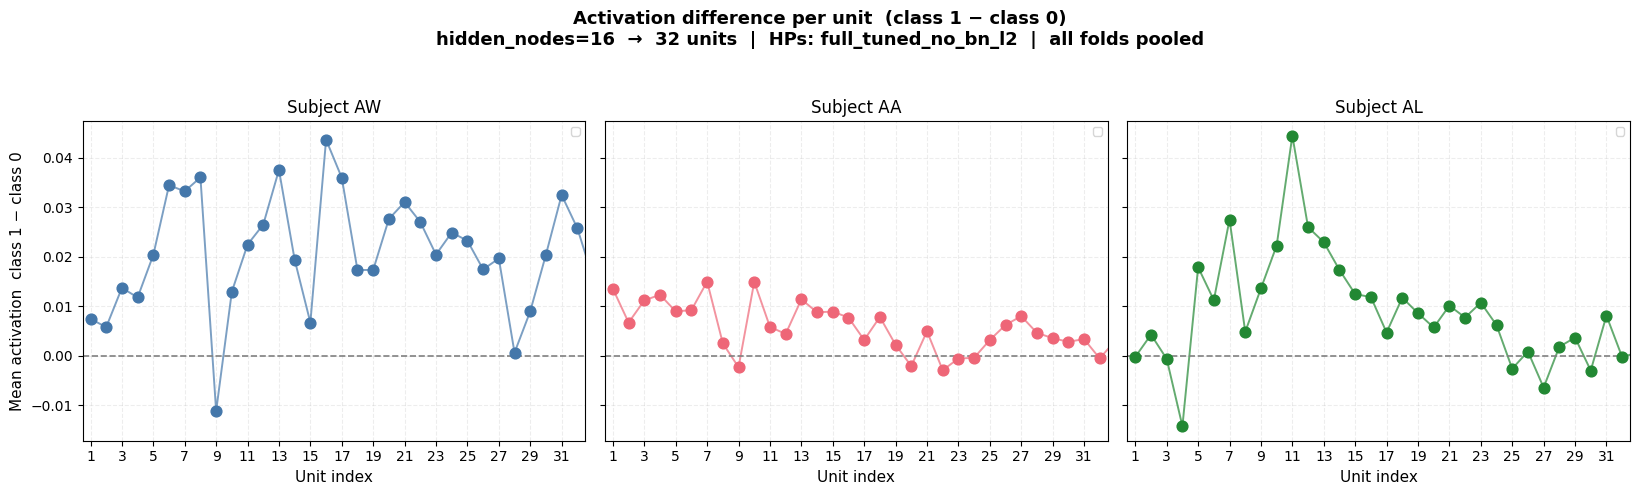

In [ ]:
fig, axes = plt.subplots(
    1, len(SUBJECTS),
    figsize=(5.5 * len(SUBJECTS), 5),
    sharey=True,
)

for ax, subject in zip(axes, SUBJECTS):
    g = df[df["Subject"] == subject].sort_values("unit")

    ax.scatter(g["unit"], g["diff"],
               color=SUBJ_COLOR[subject], s=60, zorder=4)
    ax.plot(g["unit"], g["diff"],
            color=SUBJ_COLOR[subject], lw=1.4, alpha=0.7)
    ax.axhline(0, color="gray", lw=1.2, linestyle="--", zorder=2)

    ax.set_xlim(0.5, n_units + 0.5)
    ax.set_xticks(np.arange(1, n_units + 1, 2))
    ax.set_xlabel("Unit index", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Mean activation  class 1 − class 0", fontsize=11)
    ax.set_title(f"Subject {subject.upper()}", fontsize=12)
    ax.grid(True, alpha=0.22, linestyle="--")
    ax.legend(fontsize=8, framealpha=0.8, loc="upper right")

fig.suptitle(
    f"Activation difference per unit  (class 1 − class 0)\n"
    f"hidden_nodes={FIXED_HN}  →  {n_units} units  |  "
    f"HPs: full_tuned_no_bn_l2  |  all folds pooled",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

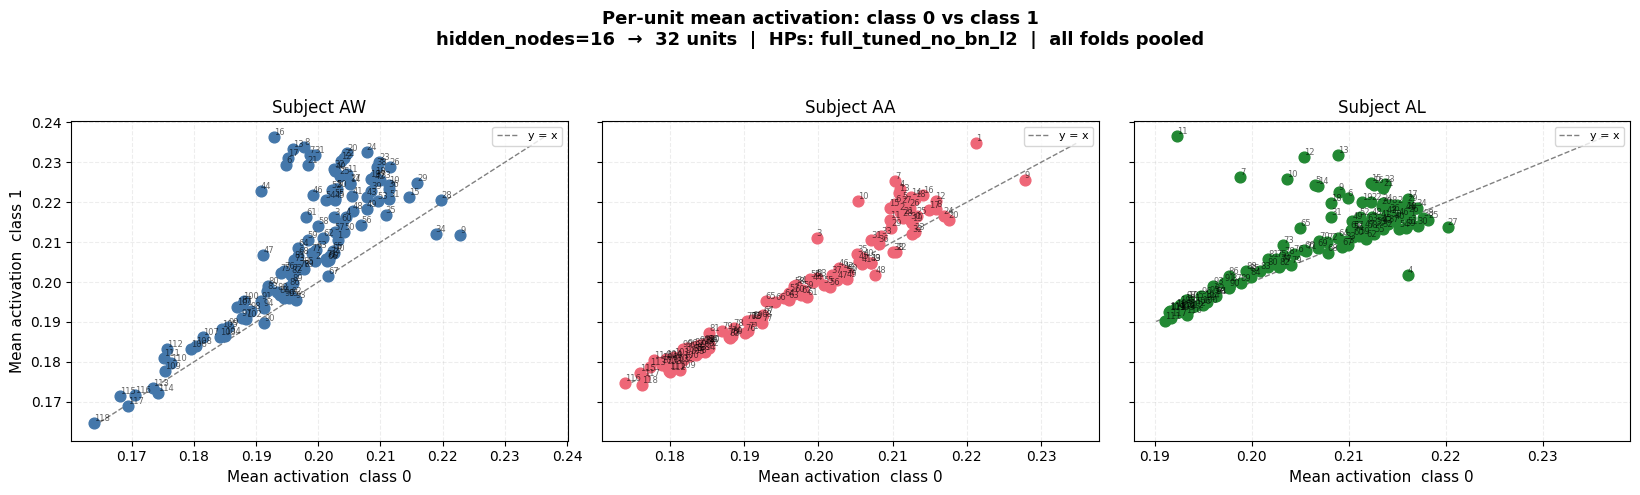

In [ ]:
SUBJ_COLOR = {s: c for s, c in zip(SUBJECTS, ["#4477AA", "#EE6677", "#228833"])}

fig, axes = plt.subplots(
    1, len(SUBJECTS),
    figsize=(5.5 * len(SUBJECTS), 5),
    sharey=True,
)
for ax, subject in zip(axes, SUBJECTS):
    g = df[df["Subject"] == subject].sort_values("unit")
    ax.scatter(g["m0"], g["m1"],
               color=SUBJ_COLOR[subject], s=60, zorder=3)
    for _, row in g.iterrows():
        ax.text(row["m0"], row["m1"], str(int(row["unit"])),
                fontsize=6, ha="left", va="bottom", alpha=0.6)
    lims = [min(g["m0"].min(), g["m1"].min()),
            max(g["m0"].max(), g["m1"].max())]
    ax.plot(lims, lims, color="gray", lw=1, ls="--",
            zorder=2, label="y = x")
    ax.set_xlabel("Mean activation  class 0", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Mean activation  class 1", fontsize=11)
    ax.set_title(f"Subject {subject.upper()}", fontsize=12)
    ax.grid(True, alpha=0.22, linestyle="--")
    ax.legend(fontsize=8, framealpha=0.8, loc="upper right")
fig.suptitle(
    f"Per-unit mean activation: class 0 vs class 1\n"
    f"hidden_nodes={FIXED_HN}  →  {n_units} units  |  "
    f"HPs: full_tuned_no_bn_l2  |  all folds pooled",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:
# ================================================================
# SCATTER: Mean raw channel activation — class 0 (x) vs class 1 (y)
# One point per electrode channel, one panel per subject.
# Uses highpass-filtered analytic signal directly (no whitening).
# ================================================================
# Requirements: all_subject_data, filter_data, test_train, helpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

SUBJECTS    = ["aw", "aa", "al"]
FS          = 100
N_FOLDS     = 5
TRIAL_PHASE = 1
SAVE_FIGS   = False
DPI         = 150

# ── Collect mean |signal| per channel per class ───────────────────
records = []

for subject in SUBJECTS:
    print(f"\n===== SUBJECT: {subject.upper()} =====")
    cnt_data = all_subject_data[subject]["cnt_data"]
    lapID    = all_subject_data[subject]["lapID"]
    hp_data  = filter_data(cnt_data, 2, FS, "high", use_hilbert=True)

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    y             = lapTrue[:, 1] - 1

    # Pool test-set samples across folds (no whitening)
    all_data, all_y = [], []
    for fold in range(N_FOLDS):
        test_inds, train_inds = test_train(
            lapTrue, TRIAL_PHASE, n_folds=N_FOLDS, which_fold=fold
        )
        all_data.append(valid_hp_data[test_inds])
        all_y   .append(y[test_inds])

    data_all = np.concatenate(all_data, axis=0)   # (n_samples, n_ch), complex
    y_all    = np.concatenate(all_y,    axis=0)

    n_ch = data_all.shape[1]
    print(f"  n_channels={n_ch}  n_samples={len(y_all)}")

    for ch in range(n_ch):
        sig = np.abs(data_all[:, ch])   # amplitude of analytic signal
        m0 = sig[y_all == 0].mean() if (y_all == 0).any() else np.nan
        m1 = sig[y_all == 1].mean() if (y_all == 1).any() else np.nan
        records.append(dict(Subject=subject, channel=ch, m0=m0, m1=m1))

df = pd.DataFrame(records)




===== SUBJECT: AW =====
  n_channels=118  n_samples=19250

===== SUBJECT: AA =====
  n_channels=118  n_samples=58450

===== SUBJECT: AL =====
  n_channels=118  n_samples=78050


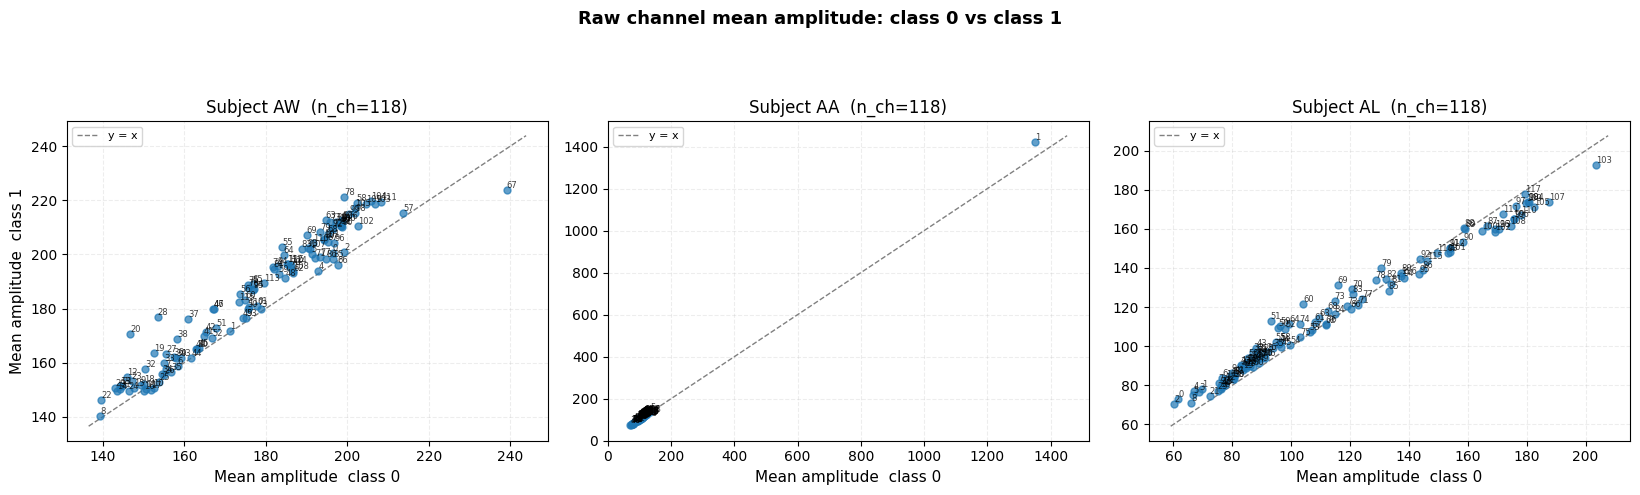

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, len(SUBJECTS),
    figsize=(5.5 * len(SUBJECTS), 5),
    sharey=False, sharex=False,
)

for ax, subject in zip(axes, SUBJECTS):
    g = df[df["Subject"] == subject].sort_values("channel")

    ax.scatter(g["m0"], g["m1"], s=25, zorder=3, alpha=0.7)

    for _, row in g.iterrows():
        ax.text(row["m0"], row["m1"], str(int(row["channel"])),
                fontsize=6, ha="left", va="bottom", alpha=0.75)

    lims = [min(g["m0"].min(), g["m1"].min()) * 0.98,
            max(g["m0"].max(), g["m1"].max()) * 1.02]
    ax.plot(lims, lims, color="gray", lw=1, ls="--", zorder=2, label="y = x")

    ax.set_xlabel("Mean amplitude  class 0", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Mean amplitude  class 1", fontsize=11)
    ax.set_title(f"Subject {subject.upper()}  (n_ch={len(g)})", fontsize=12)
    ax.legend(fontsize=8, framealpha=0.8, loc="upper left")
    ax.grid(True, alpha=0.22, linestyle="--")

fig.suptitle(
    "Raw channel mean amplitude: class 0 vs class 1\n",
    fontsize=13, fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])

if SAVE_FIGS:
    out = "scatter_raw_channels.png"
    plt.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"[✓] Saved → {out}")

plt.show()


===== SUBJECT: AW =====


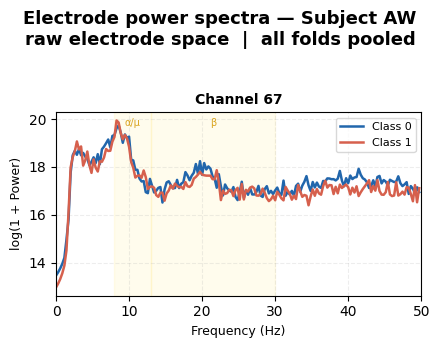

In [ ]:
# ================================================================
# POWER SPECTRA — Selected EEG electrodes per class
# Specify channels by index (0-based).
# ================================================================
# Requirements: all_subject_data, filter_data, helpers, test_train,
#               compute_power_spectrum_complex
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# ── Settings ─────────────────────────────────────────────────────
SUBJECTS         = ["aw"]
FS               = 100
N_FOLDS          = 5
TRIAL_PHASE      = 1
N_TIMES          = 350
SAVE_FIGS        = False
DPI              = 150

# ── Channels to plot (0-based indices) ───────────────────────────
CHANNEL_INDICES  = [67]

# ── Whitened (PCA) or raw electrode space ────────────────────────
# True  → columns are PCs ordered by variance (index 0 = 1st PC)
# False → columns are raw highpass-filtered electrode signals
USE_WHITENED     = True

CLASS_COLORS = {0: "#2166ac", 1: "#d6604d"}
CLASS_LABELS = {0: "Class 0", 1: "Class 1"}

# ── Run ───────────────────────────────────────────────────────────
for subject in SUBJECTS:
    print(f"\n===== SUBJECT: {subject.upper()} =====")

    cnt_data = all_subject_data[subject]["cnt_data"]
    lapID    = all_subject_data[subject]["lapID"]
    hp_data  = filter_data(cnt_data, 2, FS, "high", use_hilbert=True)

    n_ch = cnt_data.shape[1]
    invalid = [i for i in CHANNEL_INDICES if i >= n_ch]
    if invalid:
        print(f"  [!] Indices out of range (n_ch={n_ch}): {invalid}")
    channels = [i for i in CHANNEL_INDICES if i < n_ch]

    valid_mask    = lapID[:, 2].astype(bool)
    valid_hp_data = hp_data[valid_mask]
    lapTrue       = lapID[valid_mask]
    y             = lapTrue[:, 1] - 1

    # Pool test-set data across all folds
    all_wX, all_y = [], []
    for fold in range(N_FOLDS):
        test_inds, train_inds = test_train(
            lapTrue, TRIAL_PHASE, n_folds=N_FOLDS, which_fold=fold
        )
        if USE_WHITENED:
            wX, _, _ = helpers.whiten(valid_hp_data, train_inds)
            all_wX.append(wX[test_inds])
        else:
            all_wX.append(valid_hp_data[test_inds])
        all_y.append(y[test_inds])

    wX_all = np.concatenate(all_wX, axis=0)
    y_all  = np.concatenate(all_y,  axis=0)

    ncols  = min(4, len(channels))
    nrows  = int(np.ceil(len(channels) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 3.5 * nrows),
                             squeeze=False, sharey=True)
    ax_flat = axes.ravel()

    for i, ch_idx in enumerate(channels):
        ax      = ax_flat[i]
        ch_data = wX_all[:, ch_idx]

        for cls in [0, 1]:
            sel = ch_data[y_all == cls]
            freqs, power = compute_power_spectrum_complex(sel, FS, N_TIMES)
            if power is None: continue
            ax.plot(freqs, np.log1p(power),
                    color=CLASS_COLORS[cls], linewidth=1.8,
                    label=CLASS_LABELS[cls])

        for lo, hi, band_lbl in [(8, 13, "α/μ"), (13, 30, "β")]:
            ax.axvspan(lo, hi, alpha=0.07, color="gold", zorder=0)
            ax.text((lo + hi) / 2, 0.97, band_lbl,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=7, color="goldenrod")

        ax.set_title(f"Channel {ch_idx}", fontsize=10, fontweight="bold")
        ax.set_xlim(0, FS / 2)
        ax.set_xlabel("Frequency (Hz)", fontsize=9)
        if i % ncols == 0:
            ax.set_ylabel("log(1 + Power)", fontsize=9)
        ax.grid(True, alpha=0.22, linestyle="--")
        if i == 0:
            ax.legend(fontsize=8, framealpha=0.75)

    for k in range(len(channels), len(ax_flat)):
        ax_flat[k].set_visible(False)

    space_label = "whitened (PCA)" if USE_WHITENED else "raw electrode"
    fig.suptitle(
        f"Electrode power spectra — Subject {subject.upper()}\n"
        f"{space_label} space  |  all folds pooled",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if SAVE_FIGS:
        out = f"power_spectra_electrodes_{subject}.png"
        plt.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"  [✓] Saved → {out}")

    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

CLASS_COLORS = {0: "#2166ac", 1: "#d6604d"}
CLASS_LABELS = {0: "Class 0 • Hand", 1: "Class 1 • Foot"}

def load_activation_cache(cache_file):
    raw = np.load(cache_file, allow_pickle=True)
    acts = {}
    for key in raw.files:
        parts = key.split("__")
        if len(parts) != 3:
            continue
        subj, uid_s, field = parts
        acts.setdefault((subj, int(uid_s)), {})[field] = raw[key]
    print(f"[✓] Loaded {cache_file}")
    return acts


def plot_timbre_power_spectra(
    cache_file,
    hidden_nodes,
    subjects=("aa", "al", "aw"),
    fs=100,
    n_times=350,
    save_figs=True,
    dpi=150,
    title_tag="full_tuned_no_bn_l2",
):
    acts = load_activation_cache(cache_file)

    # TIMBRE hn=0 uses output-layer complex projections.
    # Binary classification => 2 complex units => Re/Im split gives 4 cached units.
    n_units = hidden_nodes if hidden_nodes > 0 else 2

    ncols = 2
    nrows = int(np.ceil(n_units / ncols))

    for subject in subjects:
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(4.5 * ncols, 3.2 * nrows),
            squeeze=False,
            sharey=True
        )
        ax_flat = axes.ravel()

        for uid in range(n_units):
            ax = ax_flat[uid]
            key = (subject, uid)

            if key not in acts:
                ax.set_visible(False)
                continue

            signal = acts[key]["acts"]
            labels = acts[key]["labels"]

            for cls in [0, 1]:
                sel = signal[labels == cls]
                freqs, power = compute_power_spectrum_complex(sel, fs, n_times)
                if power is None:
                    continue
                ax.plot(
                    freqs, np.log1p(power),
                    color=CLASS_COLORS[cls],
                    linewidth=1.6,
                    label=CLASS_LABELS[cls]
                )

            for lo, hi, band_lbl in [(8, 13, "α/μ"), (13, 30, "β")]:
                ax.axvspan(lo, hi, alpha=0.07, color="gold", zorder=0)
                ax.text(
                    (lo + hi) / 2, 0.97, band_lbl,
                    transform=ax.get_xaxis_transform(),
                    ha="center", va="top",
                    fontsize=7,
                    color="goldenrod"
                )

            ax.set_title(f"Unit {uid + 1}", fontsize=9)
            ax.set_xlim(0, fs / 2)
            ax.set_xlabel("Frequency (Hz)", fontsize=8)

            if uid % ncols == 0:
                ax.set_ylabel("log(Power)", fontsize=8)

            ax.grid(True, alpha=0.22, linestyle="--")

            if uid == 0:
                ax.legend(fontsize=8, framealpha=0.75)

        for k in range(n_units, len(ax_flat)):
            ax_flat[k].set_visible(False)

        fig.suptitle(
            f"Power Spectra — TIMBRE hn={hidden_nodes} | Subject {subject.upper()}\n",
            fontsize=13,
            fontweight="bold"
        )
        plt.tight_layout(rect=[0, 0, 1, 0.95])


        if save_figs:
            out = f"power_spectra_TIMBRE_hn{hidden_nodes}_{subject}.png"
            plt.savefig(out, dpi=dpi, bbox_inches="tight")
            print(f"[✓] Saved → {out}")

        plt.show()

[✓] Saved → power_ccsp_fixedhp_aw.png


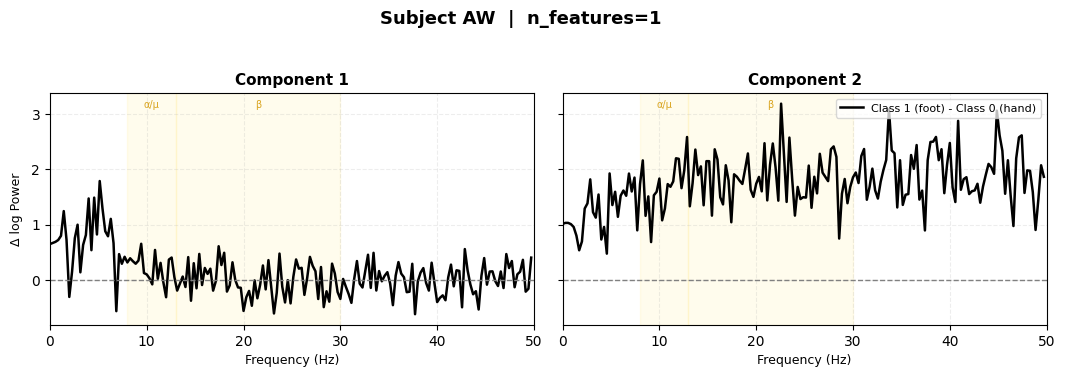

[✓] Saved → power_ccsp_fixedhp_aa.png


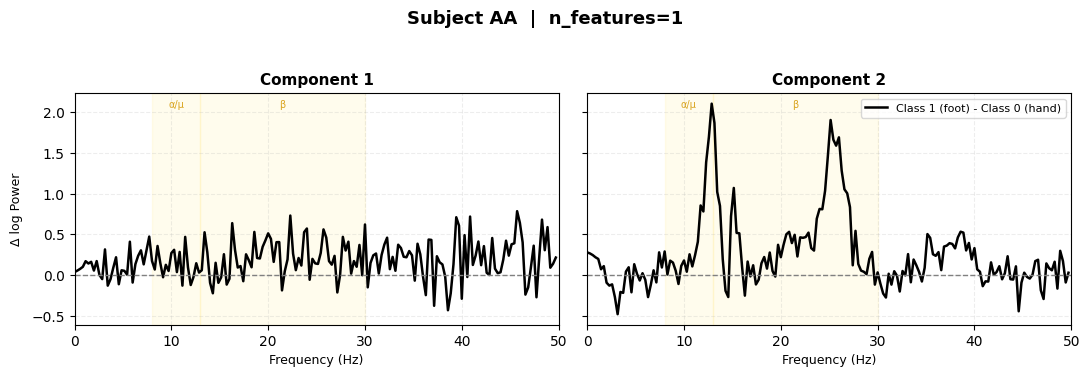

[✓] Saved → power_ccsp_fixedhp_al.png


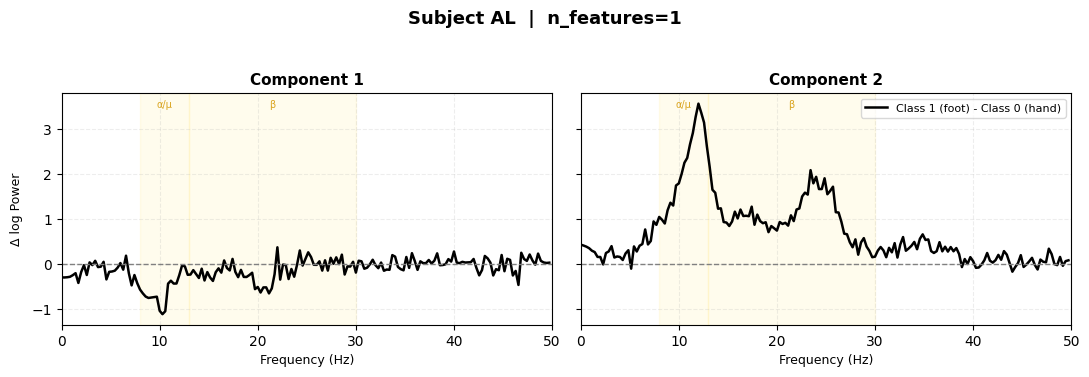


All cCSP fixed-HP power-difference plots complete.


In [ ]:
for subject in SUBJECTS:
    sdata = spec[subject]
    if not sdata:
        print(f"[!] No data for {subject}")
        continue

    cfg = fixed_cfg   # or subj_cfgs[subject] if you switch above
    n_comps = len(sdata)

    fig, axes = plt.subplots(
        1, n_comps,
        figsize=(5.5 * n_comps, 3.8),
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    axes = axes[0]

    for cid in sorted(sdata.keys()):
        ax  = axes[cid]
        z   = sdata[cid]["z"]
        lbl = sdata[cid]["labels"]

        sel0 = z[lbl == 0]
        sel1 = z[lbl == 1]

        f0, P0 = compute_power_spectrum_complex(sel0, FS, N_TIMES)
        f1, P1 = compute_power_spectrum_complex(sel1, FS, N_TIMES)

        if P0 is not None and P1 is not None and np.allclose(f0, f1):
            diff = np.log1p(P1) - np.log1p(P0)

            ax.plot(
                f0,
                diff,
                color="black",
                linewidth=1.8,
                label="Class 1 (foot) - Class 0 (hand)"
            )
            ax.axhline(0, color="gray", linestyle="--", linewidth=1)

        for lo, hi, band_lbl in [(8, 13, "α/μ"), (13, 30, "β")]:
            ax.axvspan(lo, hi, alpha=0.07, color="gold", zorder=0)
            ax.text(
                (lo + hi) / 2, 0.97, band_lbl,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                fontsize=7, color="goldenrod"
            )

        ax.set_xlim(0, FS / 2)
        ax.grid(True, alpha=0.22, linestyle="--")
        ax.set_title(f"Component {cid + 1}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Frequency (Hz)", fontsize=9)

        if cid == 0:
            ax.set_ylabel("Δ log Power", fontsize=9, labelpad=6)

        if cid == n_comps - 1:
            ax.legend(fontsize=8, framealpha=0.75, loc="upper right")

    fig.suptitle(
        # f"Power Difference — cCSP (optimised)\n"
        f"Subject {subject.upper()}  |  "
        f"n_features={cfg['n_features']}",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    if SAVE_FIGS:
        out = f"power_ccsp_fixedhp_{subject}.png"
        plt.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"[✓] Saved → {out}")

    plt.show()

print("\nAll cCSP fixed-HP power-difference plots complete.")

# 10. VERIFY BEFORE DELETE — Trial Leakage Diagnostics


In [ ]:
def _to_mask(idx_or_mask, N):
    arr = np.asarray(idx_or_mask)
    if arr.dtype == bool:
        return arr
    m = np.zeros(N, dtype=bool)
    m[arr.astype(int)] = True
    return m

def plot_trial_split(lapTrue, train_inds, test_inds, inner_train_mask, inner_val_mask, title="Trial split"):
    """
    Plots 4 binary vectors over unique trial IDs:
      - Outer TRAIN trials
      - Outer TEST trials
      - Inner TRAIN trials
      - Inner VAL trials

    1 means "this trial appears in that split" (based on ANY sample from that trial).
    """
    N = lapTrue.shape[0]
    trial_ids = lapTrue[:, 0].astype(int)
    uniq_trials = np.unique(trial_ids)

    train_mask = _to_mask(train_inds, N)
    test_mask  = _to_mask(test_inds, N)

    inner_train_mask = _to_mask(inner_train_mask, N)
    inner_val_mask   = _to_mask(inner_val_mask, N)

    def trial_vec(sample_mask):
        return np.array([int(np.any(sample_mask & (trial_ids == t))) for t in uniq_trials], dtype=int)

    outer_train_trials = trial_vec(train_mask)
    outer_test_trials  = trial_vec(test_mask)
    inner_train_trials = trial_vec(inner_train_mask)
    inner_val_trials   = trial_vec(inner_val_mask)

    # Leakage flags (trial-level)
    leak_val_outside_outer_train = (inner_val_trials == 1) & (outer_train_trials == 0)
    leak_train_outside_outer_train = (inner_train_trials == 1) & (outer_train_trials == 0)

    # Overlaps (should be False)
    overlap_outer = np.any(outer_train_trials & outer_test_trials)
    overlap_inner = np.any(inner_train_trials & inner_val_trials)

    # Plot as stacked step lines (0/1 in separate bands)
    plt.figure(figsize=(12, 3.2))
    plt.step(uniq_trials, outer_test_trials + 0, where="mid", linewidth=2)
    plt.step(uniq_trials, inner_val_trials  + 2, where="mid", linewidth=2)
    plt.step(uniq_trials, inner_train_trials+ 4, where="mid", linewidth=2)
    plt.step(uniq_trials, outer_train_trials+ 6, where="mid", linewidth=2)

    plt.yticks(
        [0, 2, 4, 6],
        ["Outer TEST", "Inner VAL", "Inner TRAIN", "Outer TRAIN"]
    )
    plt.ylim(-1, 8)
    plt.xlabel("Trial ID")
    plt.title(title)

    # Mark leak trials (inner val or inner train outside outer train)
    leak_trials = uniq_trials[leak_val_outside_outer_train | leak_train_outside_outer_train]
    if leak_trials.size:
        # mark on the Inner VAL line for visibility
        plt.scatter(leak_trials, np.full_like(leak_trials, 2), marker="x", s=80)

    plt.tight_layout()
    plt.show()

    print("Checks (trial-level):")
    print(" - Outer TRAIN/TEST overlap:", overlap_outer)
    print(" - Inner TRAIN/VAL overlap:", overlap_inner)
    print(" - # Inner VAL trials outside Outer TRAIN:", int(leak_val_outside_outer_train.sum()))
    print(" - # Inner TRAIN trials outside Outer TRAIN:", int(leak_train_outside_outer_train.sum()))